# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [35]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  3954k      0 --:--:--  0:03:47 --:--:-- 4143kk 0:00:59 --:--:-- 2125k9M    0  659M    0     0  3745k      0 --:--:--  0:03:00 --:--:-- 3818k 0  3953k      0 --:--:--  0:03:47 --:--:-- 3999k


In [47]:
!rm SUSY.csv

rm: cannot remove 'SUSY.csv': No such file or directory


In [48]:
#!gunzip SUSY.csv.gz

In [49]:
ls -lh

total 1.1G
-rw-r--r-- 1 minahal minahal  56K Feb  7 09:06 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 3 minahal minahal 4.0K Feb  7 09:10  Lab.2/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.3/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.4/
-rw-r--r-- 1 minahal minahal  57K Mar 19 18:12  Lab.6.ipynb
-rw-r--r-- 1 minahal minahal 2.4M Apr  3 15:04  Lab.7.ipynb
-rw-r--r-- 1 minahal minahal  86K Mar  7 15:42  Lab4_updatedsolutions.ipynb
-rw-r--r-- 1 minahal minahal  45K Mar  7 16:59  Lab5UpdatedSolutions.ipynb
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Labs.3/
-rw-r--r-- 1 minahal minahal 228M Apr  3 15:01  SUSY-small.csv
-rw-r--r-- 1 minahal minahal 880M Apr  3 15:04  SUSY.csv.gz
-rw-r--r-- 1 minahal minahal   14 Feb 20 23:01  Test.foo
-rw-r--r-- 1 minahal minahal   49 Mar  7 15:42  my_drawing.txt


The data is provided as a comma separated file.

In [50]:
filename="SUSY-small.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY-small.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [51]:
!ls -lh

total 1.1G
-rw-r--r-- 1 minahal minahal  56K Feb  7 09:06 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 3 minahal minahal 4.0K Feb  7 09:10  Lab.2
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.3
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.4
-rw-r--r-- 1 minahal minahal  57K Mar 19 18:12  Lab.6.ipynb
-rw-r--r-- 1 minahal minahal 2.4M Apr  3 15:04  Lab.7.ipynb
-rw-r--r-- 1 minahal minahal  86K Mar  7 15:42  Lab4_updatedsolutions.ipynb
-rw-r--r-- 1 minahal minahal  45K Mar  7 16:59  Lab5UpdatedSolutions.ipynb
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Labs.3
-rw-r--r-- 1 minahal minahal 228M Apr  3 15:01  SUSY-small.csv
-rw-r--r-- 1 minahal minahal 880M Apr  3 15:04  SUSY.csv.gz
-rw-r--r-- 1 minahal minahal   14 Feb 20 23:01  Test.foo
-rw-r--r-- 1 minahal minahal   49 Mar  7 15:42  my_drawing.txt


We see that we have 5 million datapoints.

In [52]:
!wc -l SUSY-small.csv

500000 SUSY-small.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [53]:
!head -500000 SUSY.csv > SUSY-small.csv

head: cannot open 'SUSY.csv' for reading: No such file or directory


In [54]:
!gunzip -c SUSY.csv.gz | head -500000 > SUSY-small.csv


gzip: stdout: Broken pipe


In [55]:
!wc -l SUSY-small.csv

500000 SUSY-small.csv


In [56]:
ls -lh

total 1.1G
-rw-r--r-- 1 minahal minahal  56K Feb  7 09:06 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 3 minahal minahal 4.0K Feb  7 09:10  Lab.2/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.3/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.4/
-rw-r--r-- 1 minahal minahal  57K Mar 19 18:12  Lab.6.ipynb
-rw-r--r-- 1 minahal minahal 2.4M Apr  3 15:04  Lab.7.ipynb
-rw-r--r-- 1 minahal minahal  86K Mar  7 15:42  Lab4_updatedsolutions.ipynb
-rw-r--r-- 1 minahal minahal  45K Mar  7 16:59  Lab5UpdatedSolutions.ipynb
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Labs.3/
-rw-r--r-- 1 minahal minahal 228M Apr  3 15:05  SUSY-small.csv
-rw-r--r-- 1 minahal minahal 880M Apr  3 15:04  SUSY.csv.gz
-rw-r--r-- 1 minahal minahal   14 Feb 20 23:01  Test.foo
-rw-r--r-- 1 minahal minahal   49 Mar  7 15:42  my_drawing.txt


In [57]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [58]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [59]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [60]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [61]:
FeatureNames

['MET_rel',
 'axial_MET',
 'MT2',
 'cos_theta_r1',
 'S_R',
 'M_R',
 'dPhi_r_b',
 'R',
 'M_Delta_R',
 'M_TR_2']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [63]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [64]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [65]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


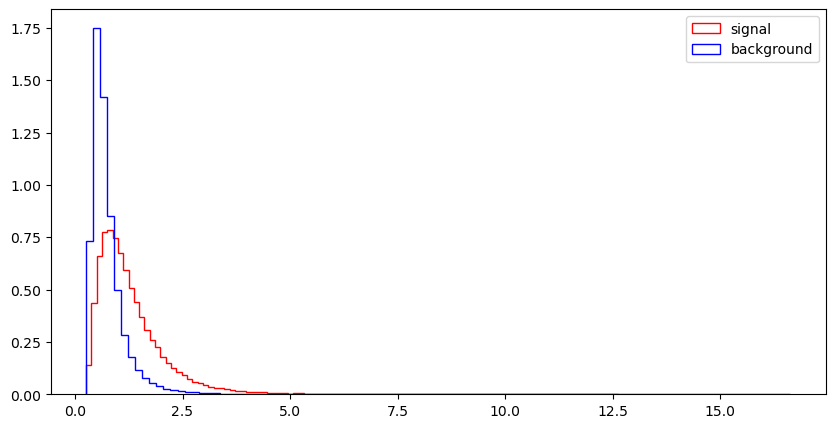

l_1_eta


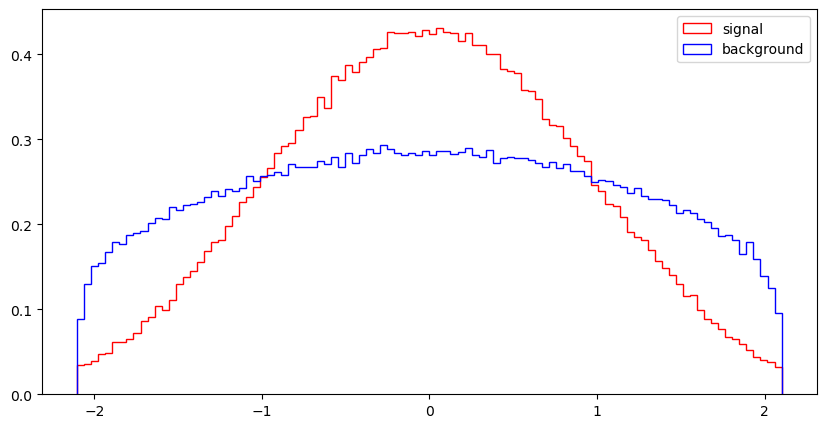

l_1_phi


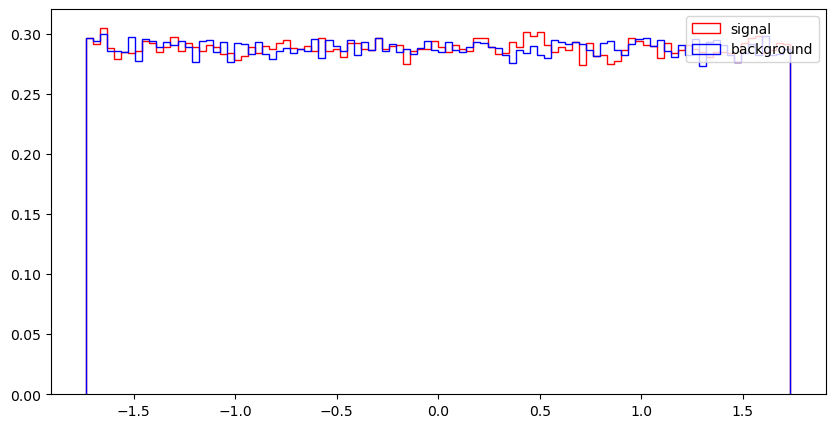

l_2_pT


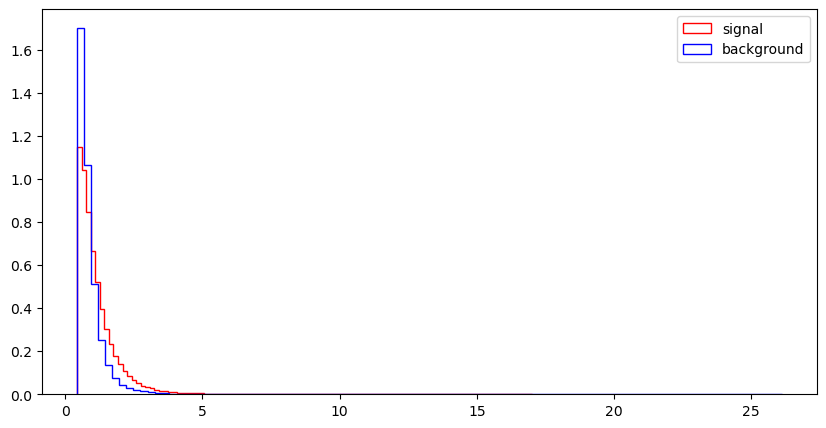

l_2_eta


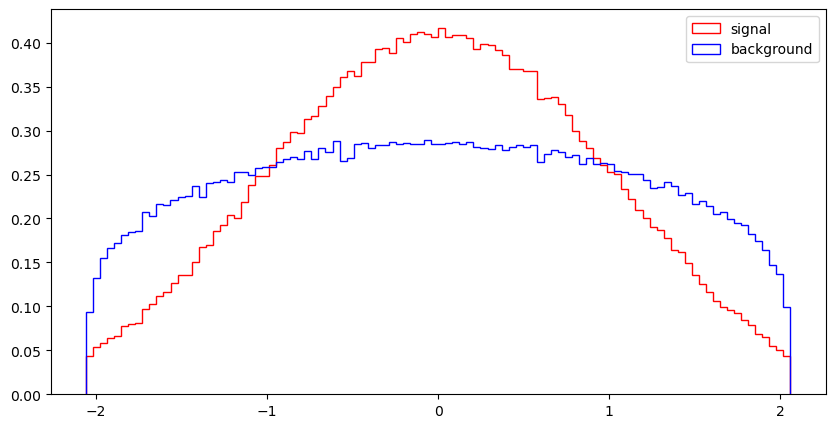

l_2_phi


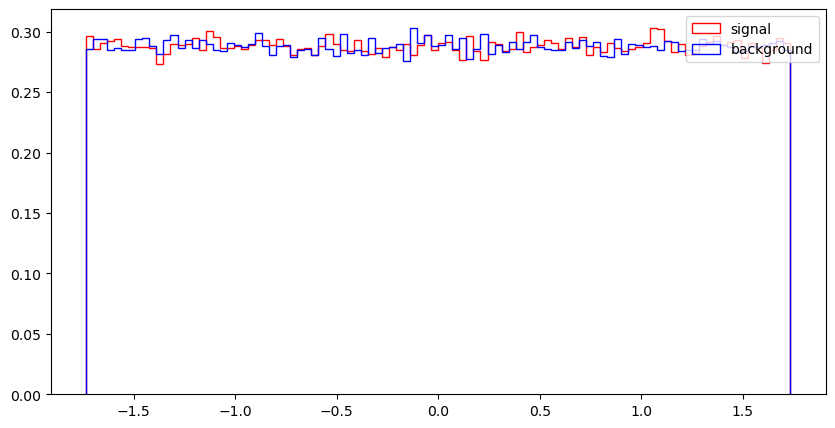

MET


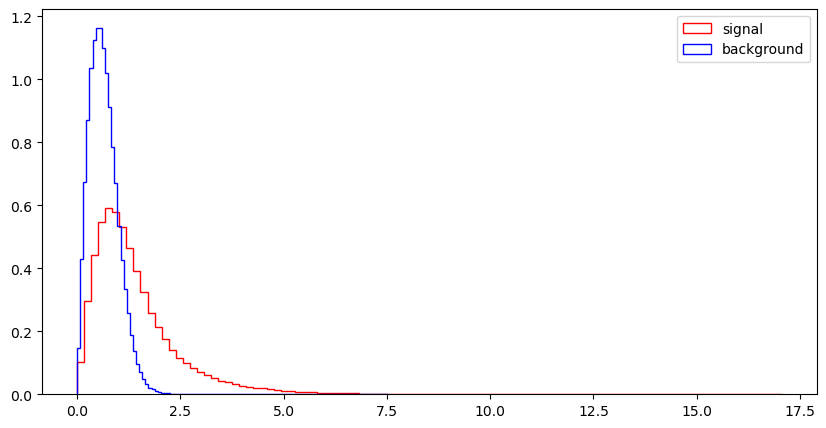

MET_phi


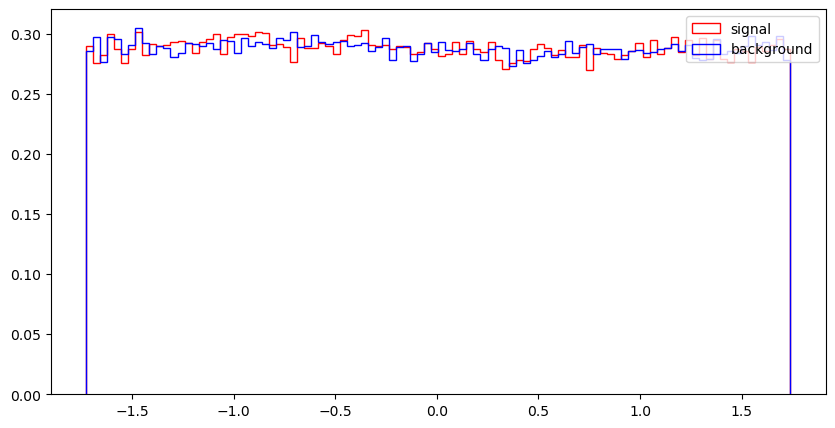

MET_rel


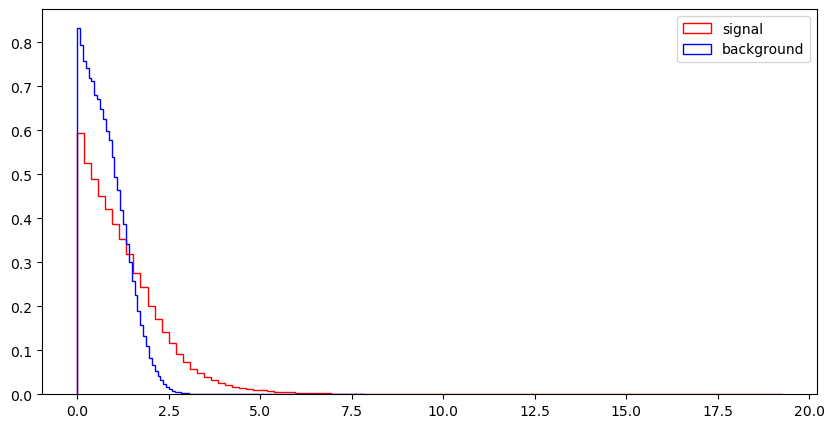

axial_MET


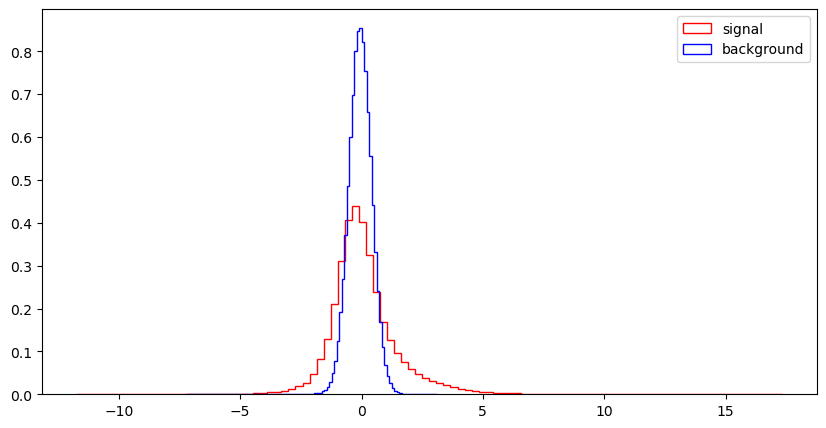

M_R


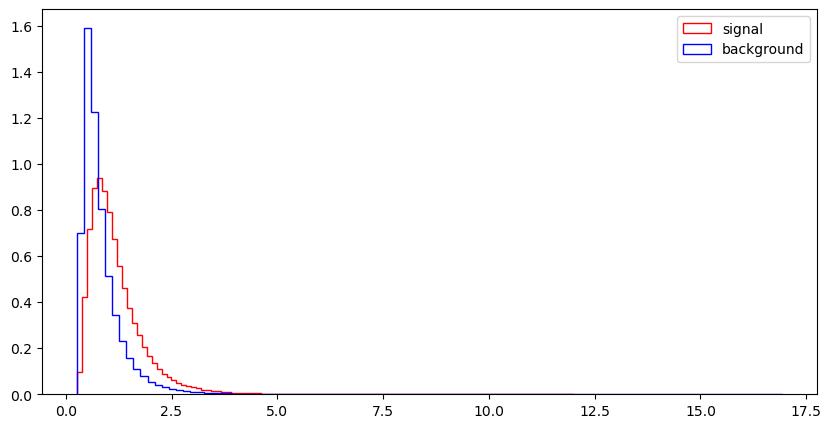

M_TR_2


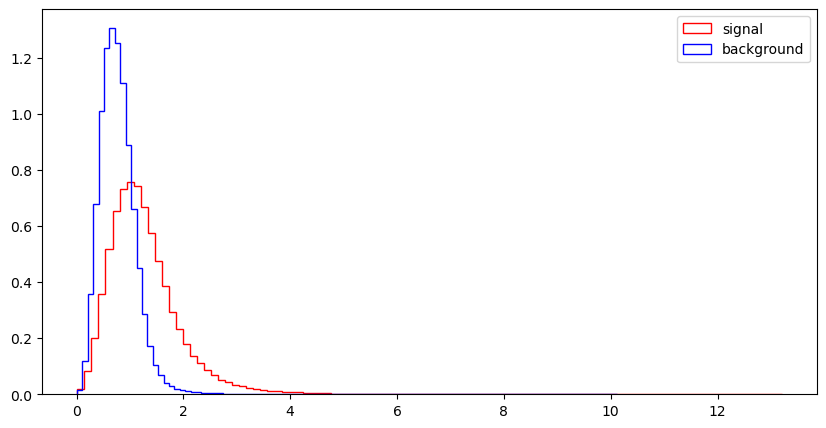

R


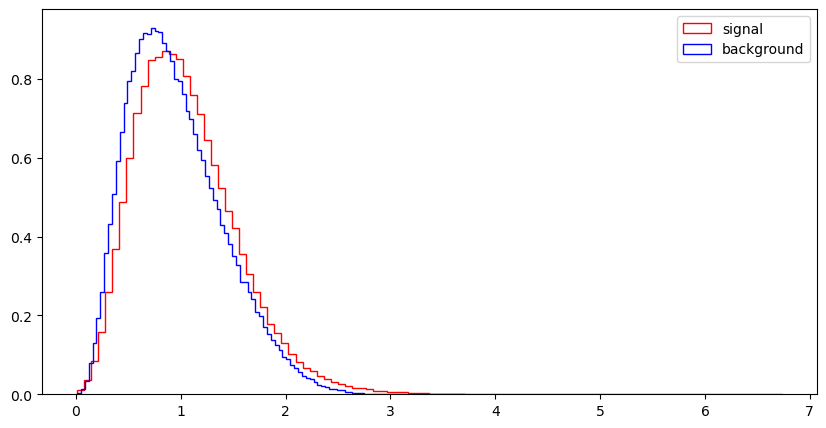

MT2


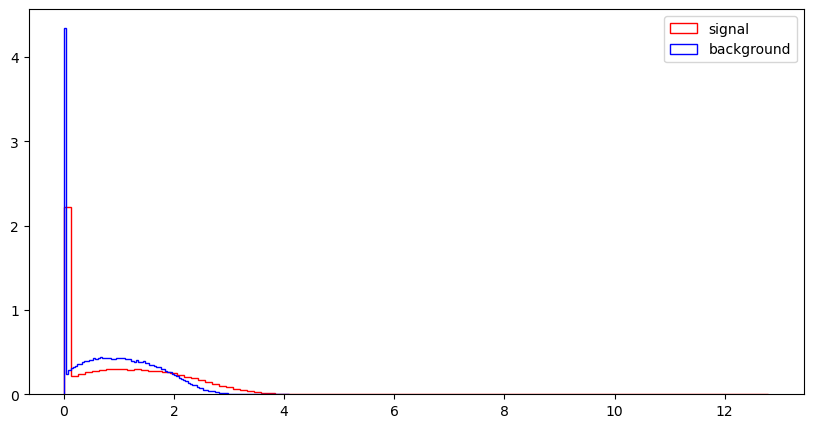

S_R


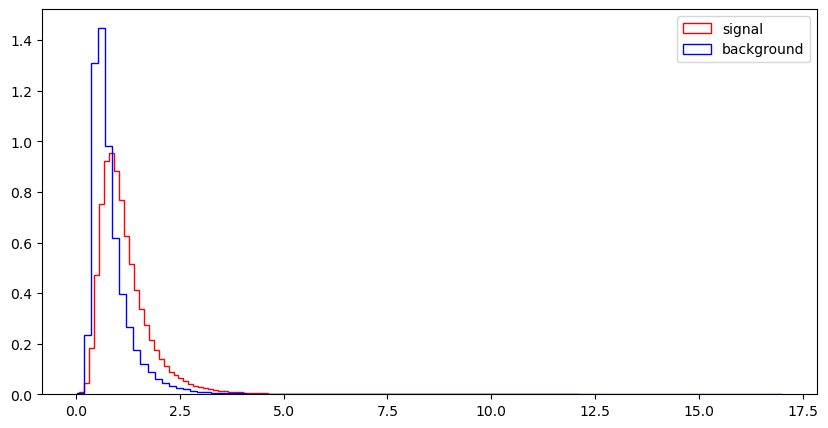

M_Delta_R


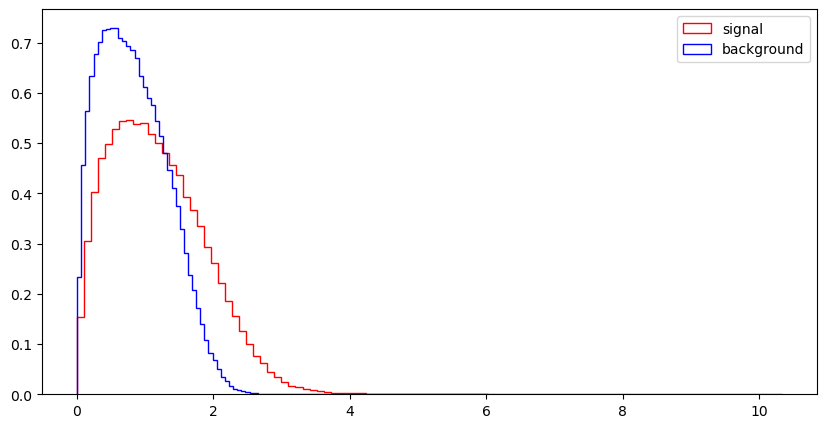

dPhi_r_b


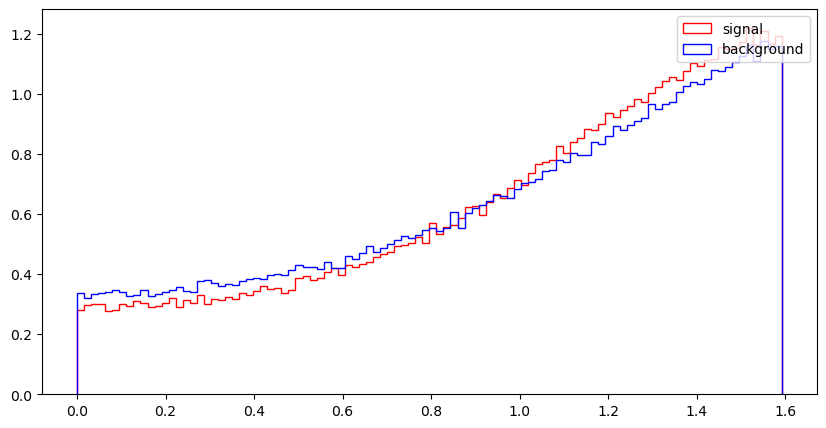

cos_theta_r1


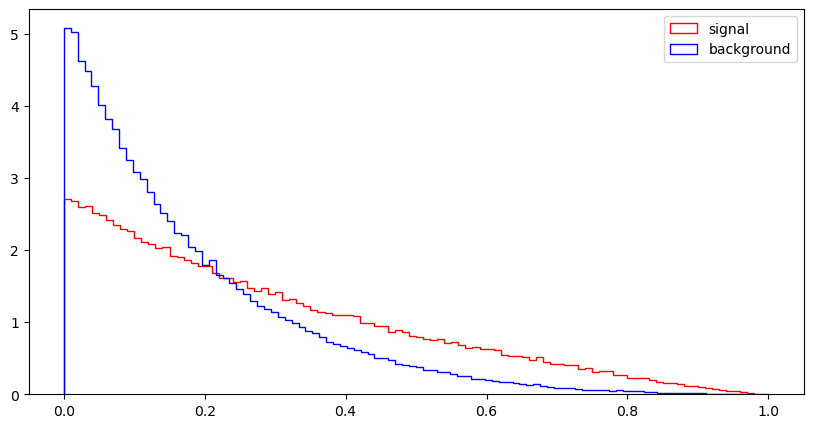

In [66]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

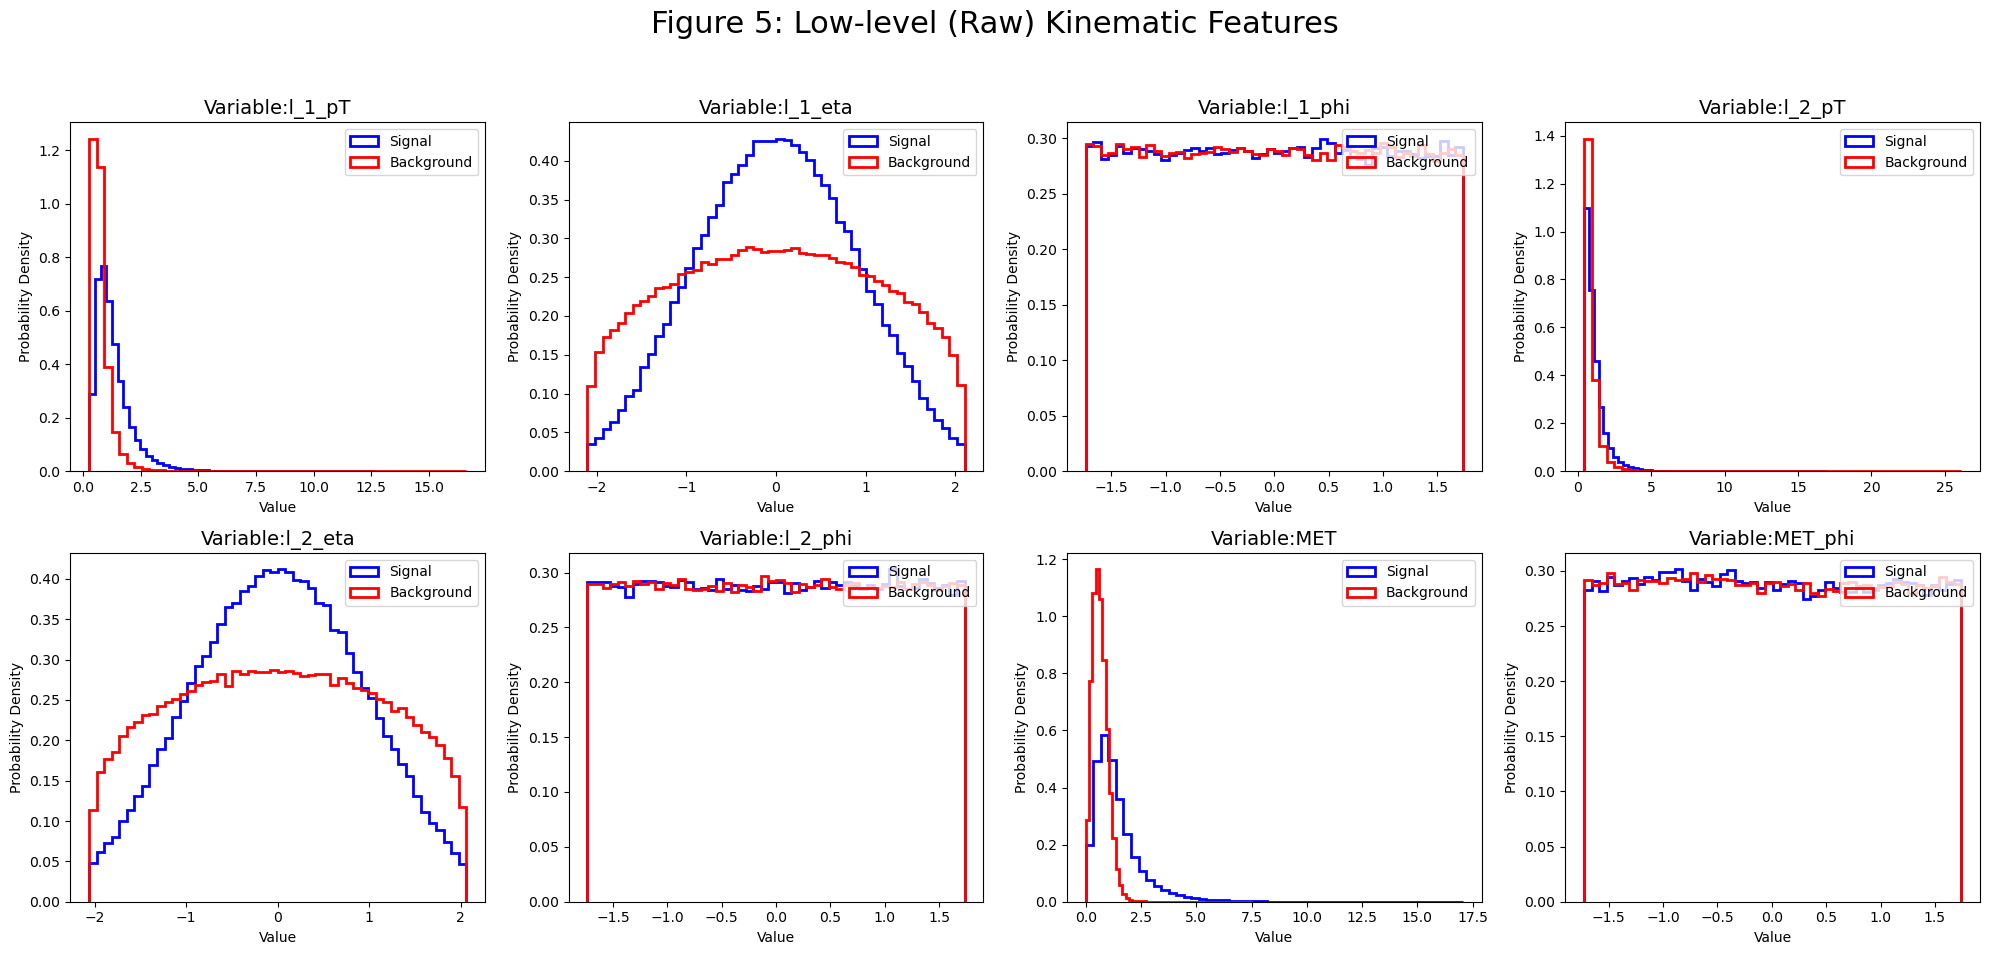

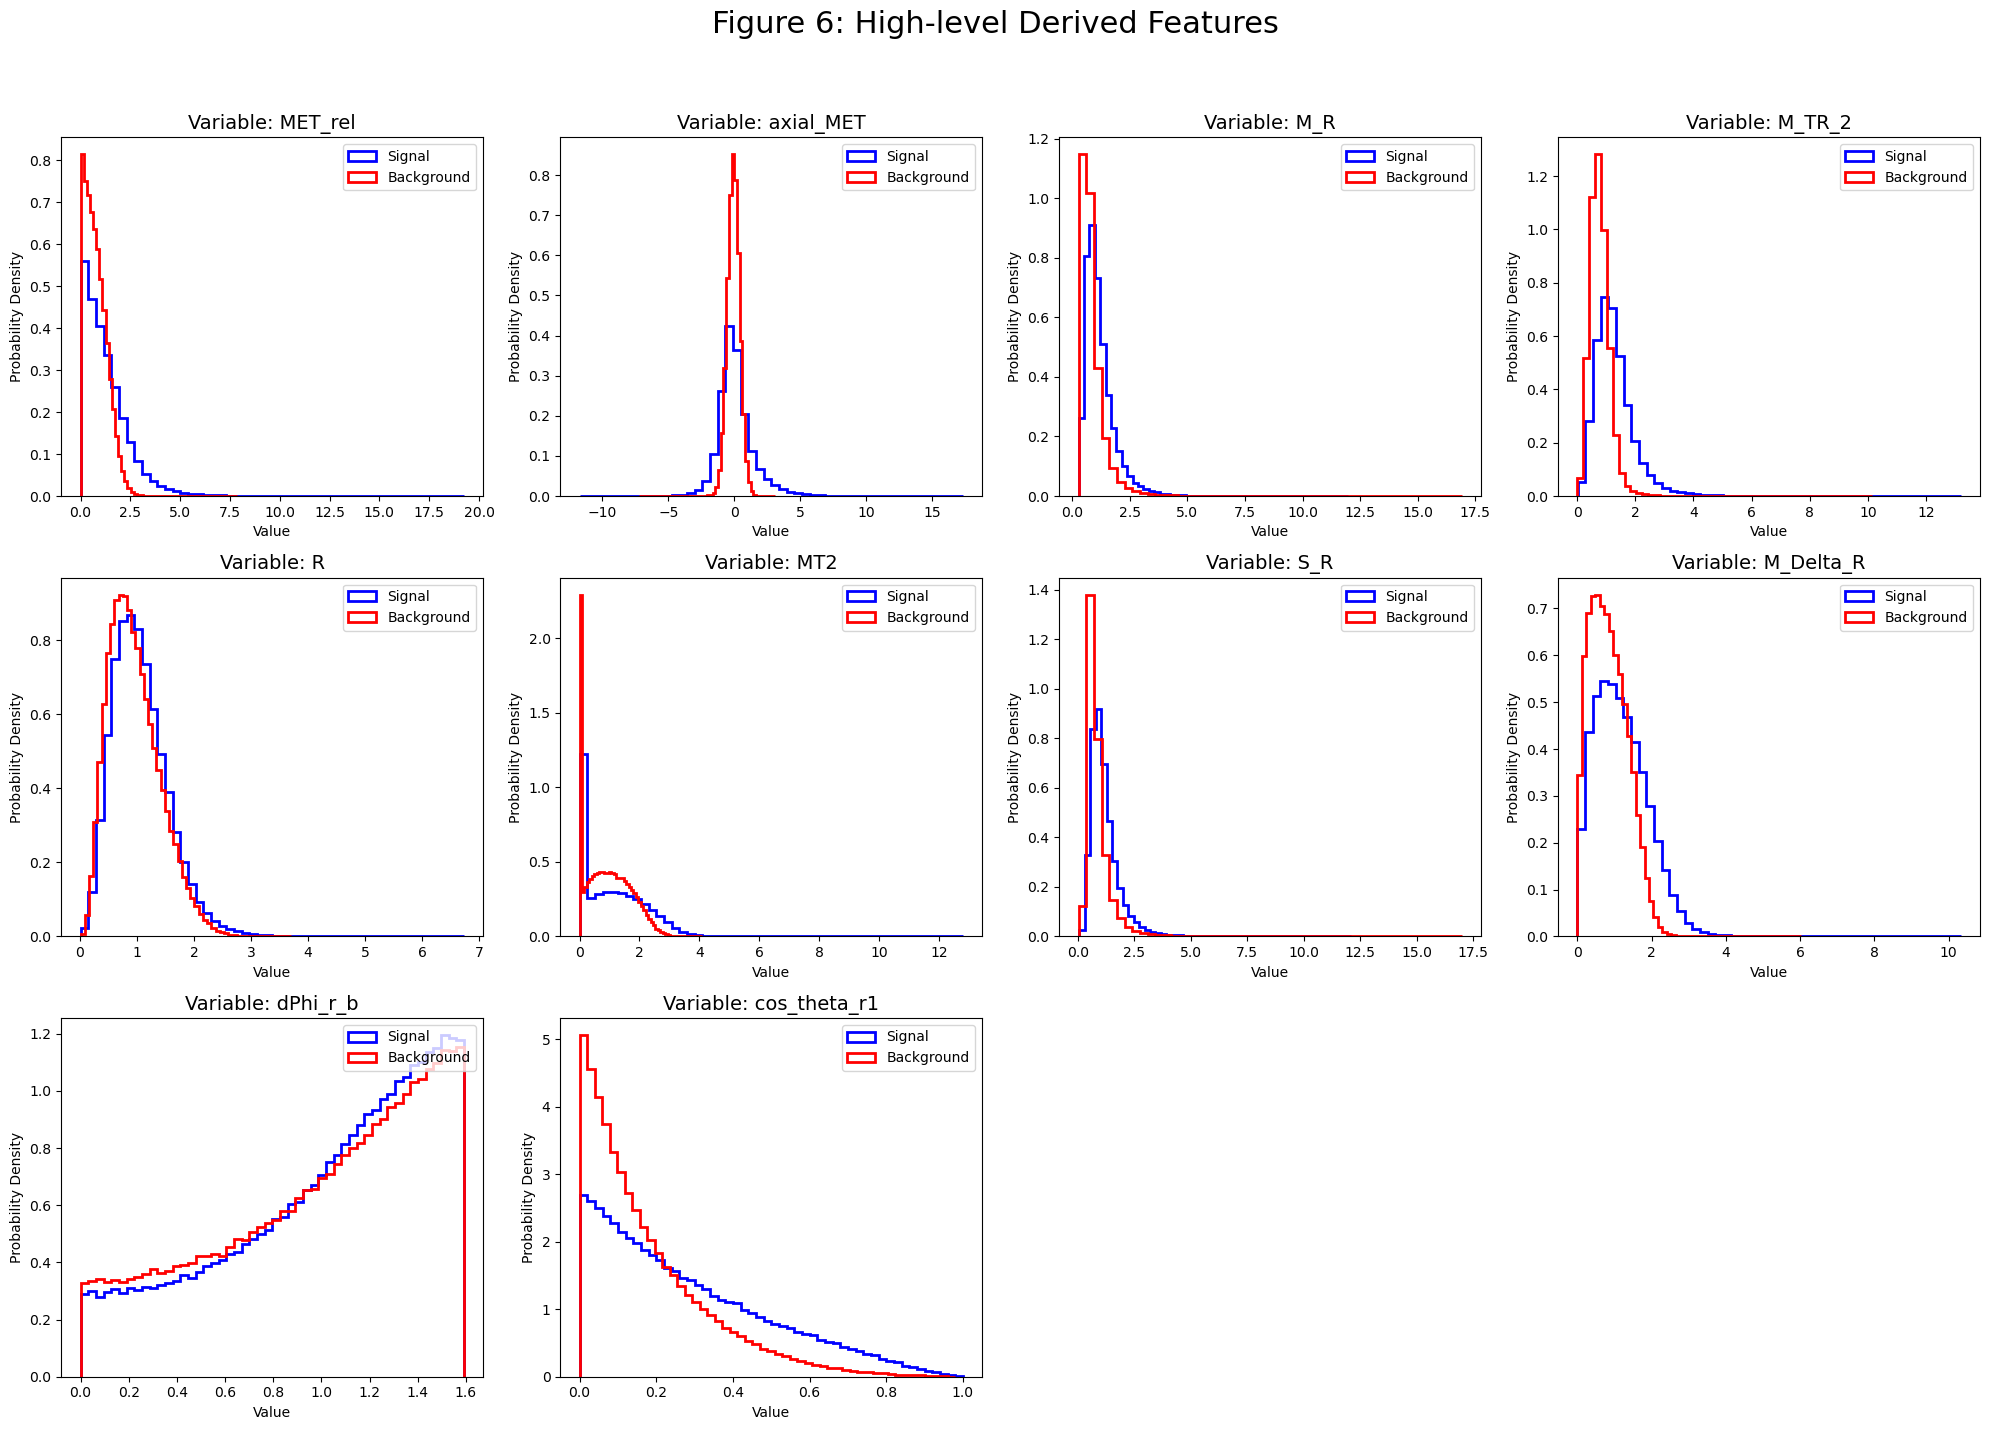

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
#The CSV file has no header so I am defining the names myself.
#signal is the target (1 or 0).The rest are measurements or featurs
VarNames=["signal","l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi", ##setting up the columns name
    "MET","MET_phi","MET_rel","axial_MET","M_R","M_TR_2","R","MT2", 
    "S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]

#I load the smaller version of the dataset to make the code run fast.
#header=None tells pandas that the first row is data, not column names.
df=pd.read_csv("SUSY-small.csv",header=None,names=VarNames)  #loading the data

# We create two separate tables: one for the 'Signal' and one for the 'Background'.
# This makes it very easy to plot them on the same chart later.
sig=df[df['signal']==1]  #splitting the data by category
bkg=df[df['signal']==0]

#raw features for figure 5:
RawNames=["l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi","MET","MET_phi"]  #defining the features group

#high level features for figure 6:
FeatureNames=[v for v in VarNames if v not in RawNames and v!='signal']  #list of all names not in rawnames and not the signal label.

fig5,axes5=plt.subplots(nrows=2,ncols=4,figsize=(20,10))  #create a grid with 2 rows and 4 columns(8 total spots)
fig5.suptitle("Figure 5: Low-level (Raw) Kinematic Features",fontsize=22)

axes5=axes5.flatten() #turning the 2D grid into a 1D list 

for i,name in enumerate(RawNames):
    axes5[i].hist(sig[name],bins=50,density=True,color='blue', 
                  histtype='step',linewidth=2,label='Signal')  #createing the thin outline look from the paper
    
    axes5[i].hist(bkg[name],bins=50,density=True,color='red', 
                  histtype='step',linewidth=2,label='Background')
    
    #adding titles and formatting for each small chart:
    axes5[i].set_title(f"Variable:{name}",fontsize=14)
    axes5[i].set_xlabel("Value")
    axes5[i].set_ylabel("Probability Density")
    axes5[i].legend(fontsize=10)

plt.tight_layout(rect=[0,0.03,1,0.95])  #cleaning up the layout
plt.show()
#creating a grid with 3 rows and 4 columns(12 total spots)
fig6,axes6=plt.subplots(nrows=3,ncols=4,figsize=(20,15))
fig6.suptitle("Figure 6: High-level Derived Features",fontsize=22)
axes6=axes6.flatten()


for i, name in enumerate(FeatureNames): #loping through 10 high level features
    axes6[i].hist(sig[name],bins=50,density=True,color='blue', 
                  histtype='step',linewidth=2,label='Signal')
    
    axes6[i].hist(bkg[name],bins=50,density=True,color='red', 
                  histtype='step',linewidth=2,label='Background')
    
    axes6[i].set_title(f"Variable: {name}",fontsize=14)
    axes6[i].set_xlabel("Value")
    axes6[i].set_ylabel("Probability Density")
    axes6[i].legend(fontsize=10)

axes6[10].set_visible(False)  #hiding last two empty boxes
axes6[11].set_visible(False)

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

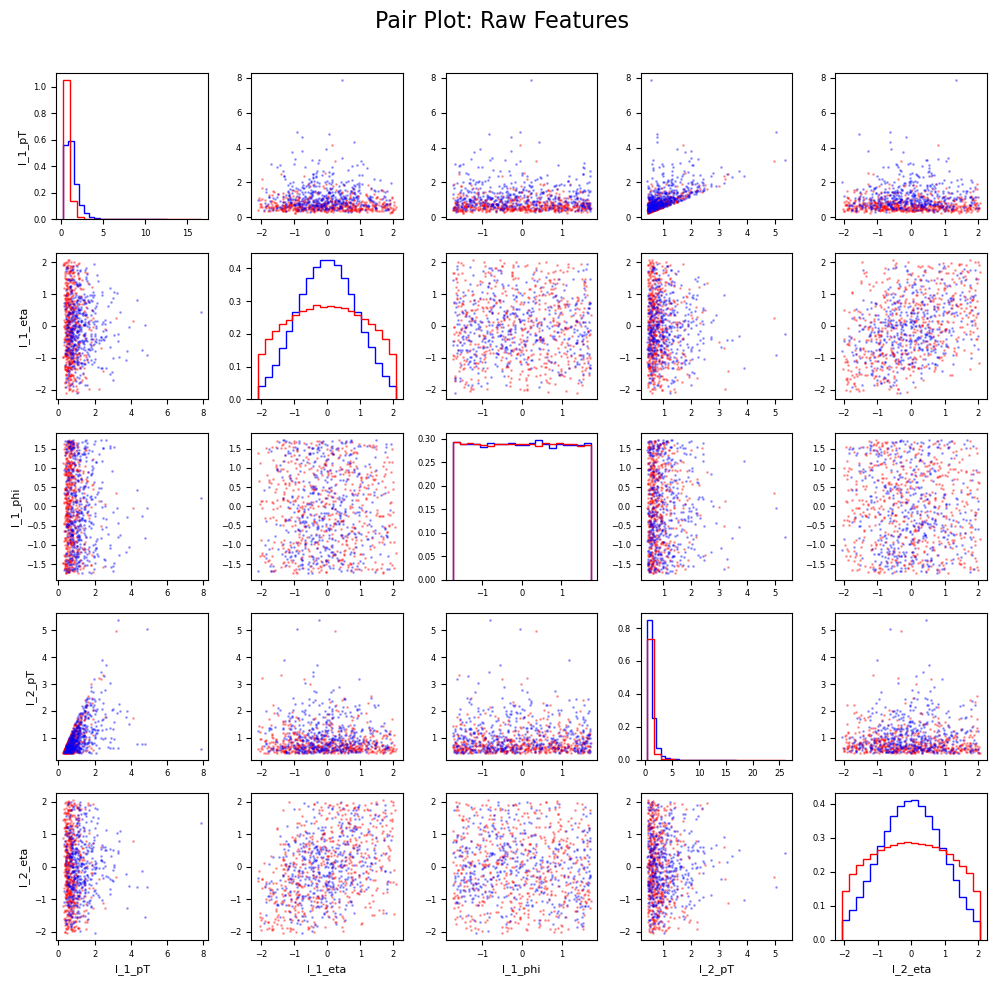

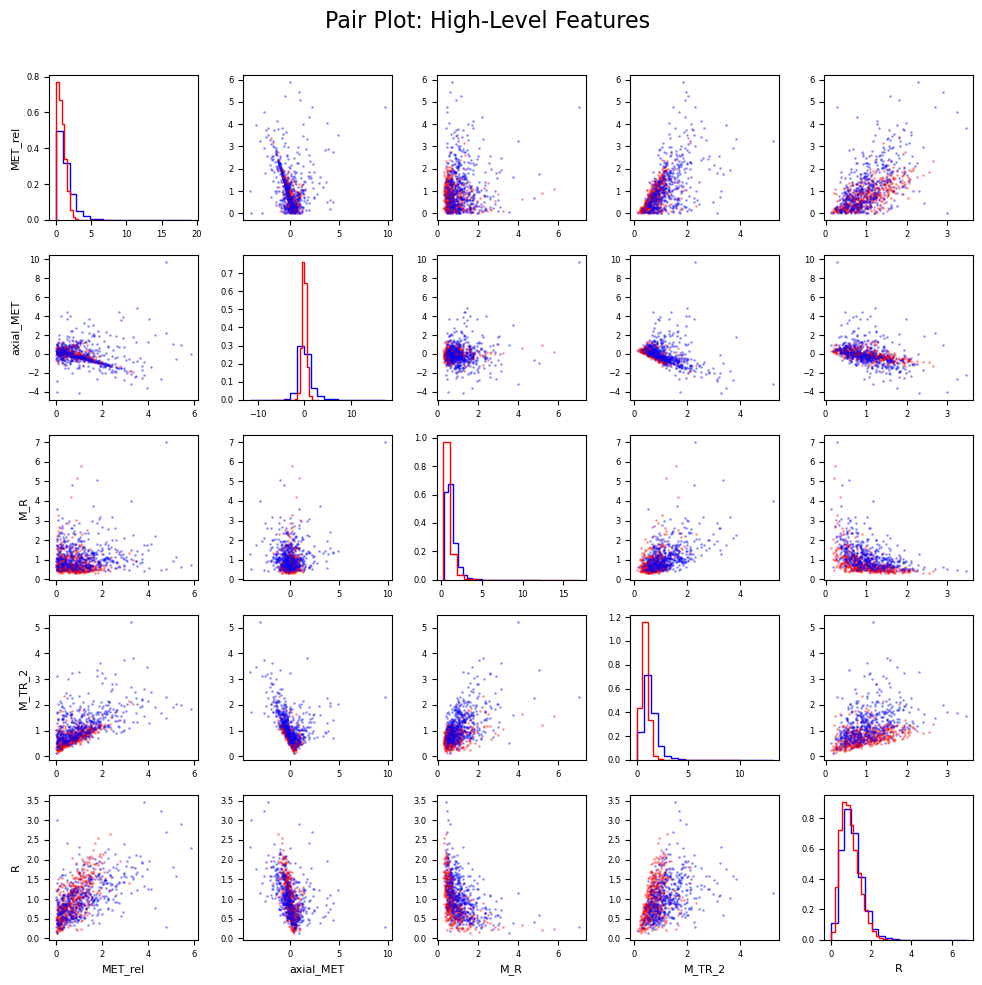

In [68]:
#part a
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#setting up names and load the data
names=["signal","l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi","MET","MET_phi","MET_rel","axial_MET","M_R","M_TR_2","R","MT2","S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]
df=pd.read_csv("SUSY-small.csv",header=None,names=names)
#splitting features into two smaller lists so the pictures are not too crowded
raw_f=names[1:6] #first 5 basic measurements
high_f=names[9:14] #first 5 smart measurements
#defining the plotting function
def make_pair_plot(data,vars,title):
    n=len(vars)
    #creating the grid for our charts
    fig,axes=plt.subplots(n,n,figsize=(n*2,n*2))
    fig.suptitle(title,fontsize=16)
    #picking 1000 random events to make the code run very fast
    sample=data.sample(1000)
    sig=sample[sample['signal']==1]
    bkg=sample[sample['signal']==0]
    for i in range(n):
        for j in range(n):
            ax=axes[i,j]
            if i==j:
                #on the diagonal line I am drawing histograms(one variable)
                ax.hist(data[data['signal']==1][vars[i]],bins=20,density=True,histtype='step',color='blue')
                ax.hist(data[data['signal']==0][vars[i]],bins=20,density=True,histtype='step',color='red')
            else:
                #everywhere else,drawing dots(two variables together)
                ax.scatter(bkg[vars[j]],bkg[vars[i]],s=1,color='red',alpha=0.3)
                ax.scatter(sig[vars[j]],sig[vars[i]],s=1,color='blue',alpha=0.3)
            #only put names on the bottom and left sides
            if i==n-1:ax.set_xlabel(vars[j],fontsize=8)
            if j==0:ax.set_ylabel(vars[i],fontsize=8)
            ax.tick_params(labelsize=6)
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()
#running the function for both sets of data
make_pair_plot(df,raw_f,"Pair Plot: Raw Features")
make_pair_plot(df,high_f,"Pair Plot: High-Level Features")

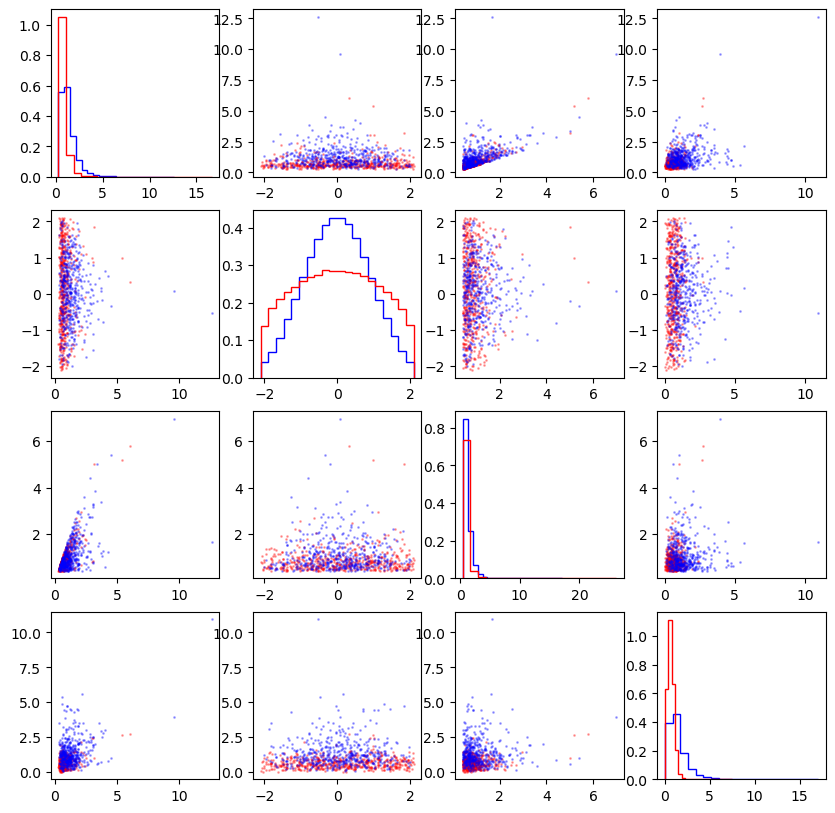

In [70]:
#part b
import pandas as pd
import matplotlib.pyplot as plt
#this function makes a fast grid of plots
cols=["signal","l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi","MET","MET_phi","MET_rel","axial_MET","M_R","M_TR_2","R","MT2","S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]
df=pd.read_csv("SUSY-small.csv",header=None,names=cols)
my_vars=["l_1_pT","l_1_eta","l_2_pT","MET"] #picking a few names to plot so it is not too slow
def fast_pair_plot(data,vars):
    n=len(vars)
    fig,axes=plt.subplots(n,n,figsize=(10,10))
    #picking 1000 random rows so the dots draw very quickly
    sample=data.sample(1000) 
    sig_s=sample[sample['signal']==1] #small group of good events
    bkg_s=sample[sample['signal']==0] #small group of noise events
    for i in range(n):
        for j in range(n):
            ax=axes[i,j]
            if i==j:
                #if row and column are same drawing a line histogram using all data
                ax.hist(data[data['signal']==1][vars[i]],bins=20,density=True,histtype='step',color='blue')
                ax.hist(data[data['signal']==0][vars[i]],bins=20,density=True,histtype='step',color='red')
            else:
                #if row and column are different: draw scatter dots using the 1000-row sample
                ax.scatter(bkg_s[vars[j]],bkg_s[vars[i]],s=1,color='red',alpha=0.3)
                ax.scatter(sig_s[vars[j]],sig_s[vars[i]],s=1,color='blue',alpha=0.3)
    plt.show()
fast_pair_plot(df,my_vars)

In [71]:
#part b:
#In this part,I focused on making the pair plots draw much faster.Normally,trying to draw a scatter plot with 500000 dots would make the computer freeze or take a very long time. 
#To fix this,I used a trick called subsampling. Instead of using every single row of data for the scatter plots,I told the computer to pick 1000 random rows using the data.sample(1000) command.
#Since 1000 dots are enough to see the general cloud shape of the data,the plots look correct but finish drawing in just a few seconds.

In [72]:
#part c:
#The high level features seem better for separating signal from background than the low level features.
#For the lowlevel variables,MET and maybe l_1_pT looked more useful than the others.Variables like eta and phi did not seem to separate the two groups very clearly.
#For the high level variables,M_R,M_TR_2,MT2,R,and MET_rel looked the most helpful.Their signal and background distributions looked more different, 
#so they seem better for classification.So in general,the high level observables seem to do a better job than the raw observables.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [73]:
%pip install tabulate --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [74]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [75]:
#part b
import numpy as np
all_vars=VarNames[1:]
low_vars=RawNames
high_vars=sorted(FeatureNames)
#extracting numpy arrays for each group of variables
X_all=df[all_vars].to_numpy()
cov_all=np.cov(X_all,rowvar=False)
corr_all=np.corrcoef(X_all,rowvar=False)
 
#repeating for low level features only
X_low=df[low_vars].to_numpy()
cov_low=np.cov(X_low,rowvar=False)
corr_low=np.corrcoef(X_low,rowvar=False)
 
#repeating for high level features only
X_high=df[high_vars].to_numpy()
cov_high=np.cov(X_high,rowvar=False)
corr_high=np.corrcoef(X_high,rowvar=False)

In [76]:
#exercise 4.2(c)
#using tabulate to print the matrices in a cleaner table
from IPython.display import HTML,display
import tabulate
 
def format_matrix_table(matrix,columns,decimals=3):
    #building a list of lists table from a matrix with row labels
    table=[]
    for i in range(len(columns)):
        #rounding each entry to specified decimal places
        row=[columns[i]]+[round(matrix[i, j],decimals) for j in range(len(columns))]
        table.append(row)
    return table

In [77]:
#covariance matrix for all observables
print("Covariance Matrix - All Observables")
table=format_matrix_table(cov_all, all_vars, decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+all_vars)))
 
#correlation matrix for all observables
print("\nCorrelation Matrix - All Observables")
table=format_matrix_table(corr_all,all_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+all_vars)))
 
#covariance matrix for low-level features
print("\nCovariance Matrix - Low-Level Features")
table=format_matrix_table(cov_low,low_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+low_vars)))
 
#correlation matrix for low-level features
print("\nCorrelation Matrix - Low-Level Features")
table=format_matrix_table(corr_low,low_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+low_vars)))
 
#covariance matrix for high-level features
print("\nCovariance Matrix - High-Level Features")
table=format_matrix_table(cov_high,high_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+high_vars)))
 
#correlation matrix for high-level features
print("\nCorrelation Matrix - High-Level Features")
table=format_matrix_table(corr_high,high_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+high_vars)))

Covariance Matrix - All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054



Correlation Matrix - All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272



Covariance Matrix - Low-Level Features


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1



Covariance Matrix - High-Level Features


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,0.79,0.409,0.415,0.044,0.302,0.249,0.082,-0.12,0.055,0.146
MT2,0.409,0.738,0.433,-0.037,0.189,0.232,-0.011,-0.461,0.045,0.021
M_Delta_R,0.415,0.433,0.389,0.074,0.242,0.165,0.096,-0.233,0.039,0.042
M_R,0.044,-0.037,0.074,0.392,0.21,-0.113,0.38,0.017,-0.014,-0.029
M_TR_2,0.302,0.189,0.242,0.21,0.338,0.104,0.228,-0.185,0.052,0.058
R,0.249,0.232,0.165,-0.113,0.104,0.222,-0.083,-0.181,0.058,0.087
S_R,0.082,-0.011,0.096,0.38,0.228,-0.083,0.382,-0.041,-0.01,-0.003
axial_MET,-0.12,-0.461,-0.233,0.017,-0.185,-0.181,-0.041,1.005,-0.054,-0.025
cos_theta_r1,0.055,0.045,0.039,-0.014,0.052,0.058,-0.01,-0.054,0.039,0.009
dPhi_r_b,0.146,0.021,0.042,-0.029,0.058,0.087,-0.003,-0.025,0.009,0.19



Correlation Matrix - High-Level Features


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,1,0.535,0.748,0.078,0.584,0.595,0.15,-0.134,0.316,0.378
MT2,0.535,1,0.809,-0.068,0.379,0.574,-0.021,-0.535,0.264,0.056
M_Delta_R,0.748,0.809,1,0.189,0.668,0.564,0.249,-0.373,0.319,0.155
M_R,0.078,-0.068,0.189,1,0.577,-0.383,0.981,0.027,-0.116,-0.106
M_TR_2,0.584,0.379,0.668,0.577,1,0.38,0.635,-0.317,0.451,0.229
R,0.595,0.574,0.564,-0.383,0.38,1,-0.287,-0.383,0.627,0.424
S_R,0.15,-0.021,0.249,0.981,0.635,-0.287,1,-0.067,-0.085,-0.013
axial_MET,-0.134,-0.535,-0.373,0.027,-0.317,-0.383,-0.067,1,-0.272,-0.057
cos_theta_r1,0.316,0.264,0.319,-0.116,0.451,0.627,-0.085,-0.272,1,0.106
dPhi_r_b,0.378,0.056,0.155,-0.106,0.229,0.424,-0.013,-0.057,0.106,1


In [78]:
#part d
#wrapping parts b and c into a single reusable function
#takeing a dataframe list of column names and optional decimals
 
def show_cov_corr_tables(df,columns,decimals=3):
    #computing covariance and correlation matrices for the given columns and embedding them as HTML tables in the notebook.
 
    #extracting selected columns as a numpy array:
    X=df[columns].to_numpy()
 
    #computing covariance and correlation matrices
    cov_mat=np.cov(X,rowvar=False)
    corr_mat=np.corrcoef(X,rowvar=False)
 
    #building and displaying the covariance table
    print("Covariance Matrix")
    cov_table=format_matrix_table(cov_mat,columns,decimals=decimals)
    display(HTML(tabulate.tabulate(cov_table,tablefmt='html',headers=[""]+columns)))
 
    #building and displaying the correlation table
    print("\nCorrelation Matrix")
    corr_table=format_matrix_table(corr_mat,columns,decimals=decimals)
    display(HTML(tabulate.tabulate(corr_table,tablefmt='html',headers=[""]+columns)))
 
    return cov_mat, corr_mat

In [79]:
#testing the function on each group
print("All Observables")
cov_all,corr_all=show_cov_corr_tables(df,all_vars,decimals=3)
 
print("\n Low-Level Features")
cov_low,corr_low=show_cov_corr_tables(df,low_vars,decimals=3)
 
print("\n High-Level Features")
cov_high,corr_high=show_cov_corr_tables(df,high_vars,decimals=3)

All Observables
Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054



Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272



 Low-Level Features
Covariance Matrix


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1



 High-Level Features
Covariance Matrix


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,0.79,0.409,0.415,0.044,0.302,0.249,0.082,-0.12,0.055,0.146
MT2,0.409,0.738,0.433,-0.037,0.189,0.232,-0.011,-0.461,0.045,0.021
M_Delta_R,0.415,0.433,0.389,0.074,0.242,0.165,0.096,-0.233,0.039,0.042
M_R,0.044,-0.037,0.074,0.392,0.21,-0.113,0.38,0.017,-0.014,-0.029
M_TR_2,0.302,0.189,0.242,0.21,0.338,0.104,0.228,-0.185,0.052,0.058
R,0.249,0.232,0.165,-0.113,0.104,0.222,-0.083,-0.181,0.058,0.087
S_R,0.082,-0.011,0.096,0.38,0.228,-0.083,0.382,-0.041,-0.01,-0.003
axial_MET,-0.12,-0.461,-0.233,0.017,-0.185,-0.181,-0.041,1.005,-0.054,-0.025
cos_theta_r1,0.055,0.045,0.039,-0.014,0.052,0.058,-0.01,-0.054,0.039,0.009
dPhi_r_b,0.146,0.021,0.042,-0.029,0.058,0.087,-0.003,-0.025,0.009,0.19



Correlation Matrix


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,1,0.535,0.748,0.078,0.584,0.595,0.15,-0.134,0.316,0.378
MT2,0.535,1,0.809,-0.068,0.379,0.574,-0.021,-0.535,0.264,0.056
M_Delta_R,0.748,0.809,1,0.189,0.668,0.564,0.249,-0.373,0.319,0.155
M_R,0.078,-0.068,0.189,1,0.577,-0.383,0.981,0.027,-0.116,-0.106
M_TR_2,0.584,0.379,0.668,0.577,1,0.38,0.635,-0.317,0.451,0.229
R,0.595,0.574,0.564,-0.383,0.38,1,-0.287,-0.383,0.627,0.424
S_R,0.15,-0.021,0.249,0.981,0.635,-0.287,1,-0.067,-0.085,-0.013
axial_MET,-0.134,-0.535,-0.373,0.027,-0.317,-0.383,-0.067,1,-0.272,-0.057
cos_theta_r1,0.316,0.264,0.319,-0.116,0.451,0.627,-0.085,-0.272,1,0.106
dPhi_r_b,0.378,0.056,0.155,-0.106,0.229,0.424,-0.013,-0.057,0.106,1


Hint: Example code for embedding a `tabulate` table into a notebook:

In [80]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [81]:
#Exercise 5.1
signal=df[df["signal"]==1]
background=df[df["signal"]==0]
all_observables=VarNames[1:]

#using the signal mean as mu for the absolute value cut styles
mu_dict=dict()
for var in all_observables:
    mu_dict[var]=signal[var].mean()


def pass_selection(x,x_c,strategy,mu=None):
    #applying strategy 1:x>x_c
    if strategy==1:
        return x>x_c
    
    #applying strategy 2:x<x_c
    elif strategy==2:
        return x<x_c
    
    #applying strategy 3:|x-mu|>x_c
    elif strategy==3:
        return np.abs(x-mu)>x_c
    
    #applying strategy 4:|x-mu|<x_c
    elif strategy==4:
        return np.abs(x-mu)<x_c
    
    #handling invalid strategy values
    else:
        return np.zeros(len(x),dtype=bool)

#making a helper for computing efficiency after a cut
def efficiency(x,x_c,strategy,mu=None):
    #counting events that pass the selection
    passed=pass_selection(x,x_c,strategy,mu=mu)
    
    #returning fraction of events that pass
    return np.sum(passed)/float(len(x))


#making a helper for scanning cut values
def get_scan_values(x,strategy,n_points=100,mu=None):
    
    #scanning directly over x for one sided cuts
    if strategy==1 or strategy==2:
        return np.linspace(np.min(x),np.max(x),n_points)
    
    #scanning over distance from mu for absolute value cuts
    elif strategy==3 or strategy==4:
        d=np.abs(x-mu)
        return np.linspace(np.min(d),np.max(d),n_points)
    
    #returning an empty array for safety if strategy is invalid
    else:
        return np.array([])
#storing the best cut style for each observable
best_strategy_dict=dict()

for var in all_observables:
    
    #extracting signal and background values
    x_sig=np.array(signal[var])
    x_bkg=np.array(background[var])
    x_all=np.array(df[var])
    mu=mu_dict[var]
    
    #initializing best score tracking
    best_score=-np.inf
    best_strategy=None
    
    #checking all four strategies
    for strategy in [1,2,3,4]:
        
        #building scan values for the current strategy
        x_scan=get_scan_values(x_all,strategy,n_points=100,mu=mu)
        
        #tracking the best score for this strategy
        strategy_best_score=-np.inf
        
        for x_c in x_scan:
            
            #computing signal and background efficiencies
            eps_s=efficiency(x_sig,x_c,strategy,mu=mu)
            eps_b=efficiency(x_bkg,x_c,strategy,mu=mu)
            
            #measuring separation between signal and background
            score=eps_s-eps_b
            
            if score>strategy_best_score:
                strategy_best_score=score
        
        #updating the overall best strategy for this variable
        if strategy_best_score>best_score:
            best_score=strategy_best_score
            best_strategy=strategy
    
    best_strategy_dict[var]=best_strategy


#printing the preferred cut style for each observable
for var in all_observables:
    print(var,"-> strategy",best_strategy_dict[var])

l_1_pT -> strategy 1
l_1_eta -> strategy 4
l_1_phi -> strategy 4
l_2_pT -> strategy 1
l_2_eta -> strategy 4
l_2_phi -> strategy 3
MET -> strategy 1
MET_phi -> strategy 4
MET_rel -> strategy 1
axial_MET -> strategy 3
M_R -> strategy 1
M_TR_2 -> strategy 1
R -> strategy 1
MT2 -> strategy 3
S_R -> strategy 1
M_Delta_R -> strategy 1
dPhi_r_b -> strategy 1
cos_theta_r1 -> strategy 1


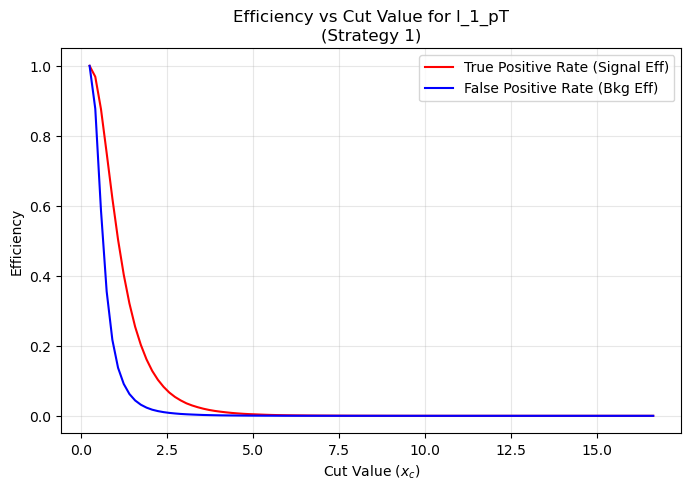

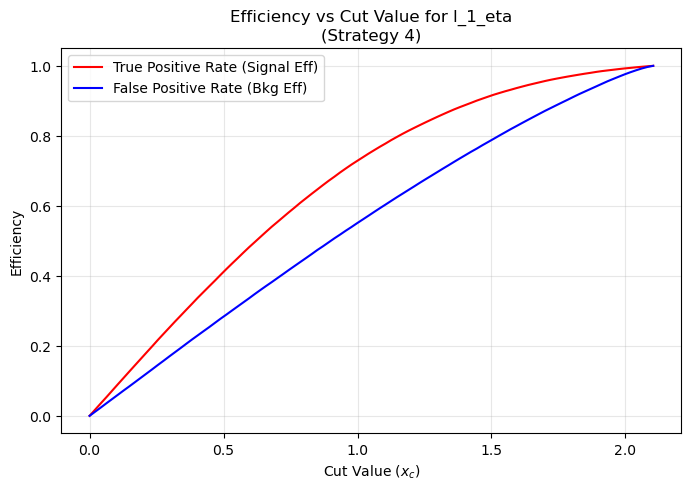

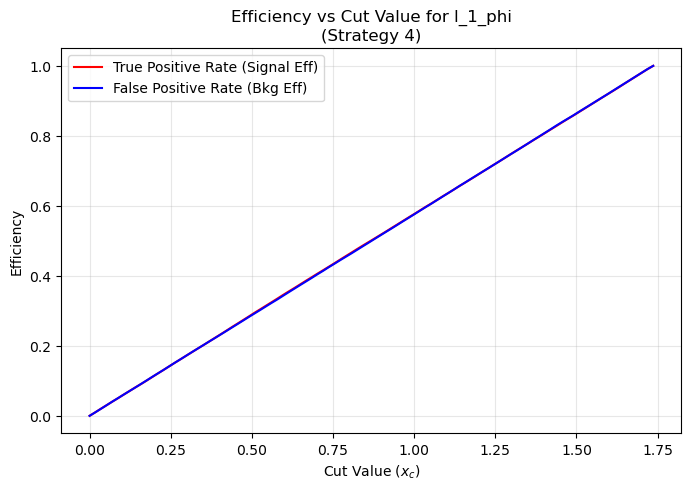

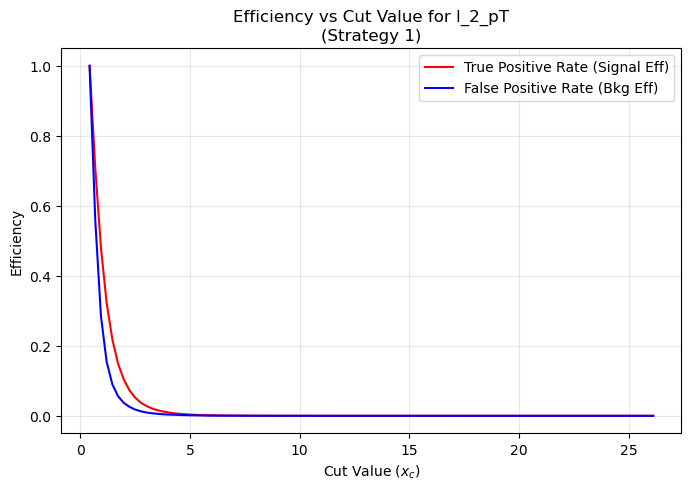

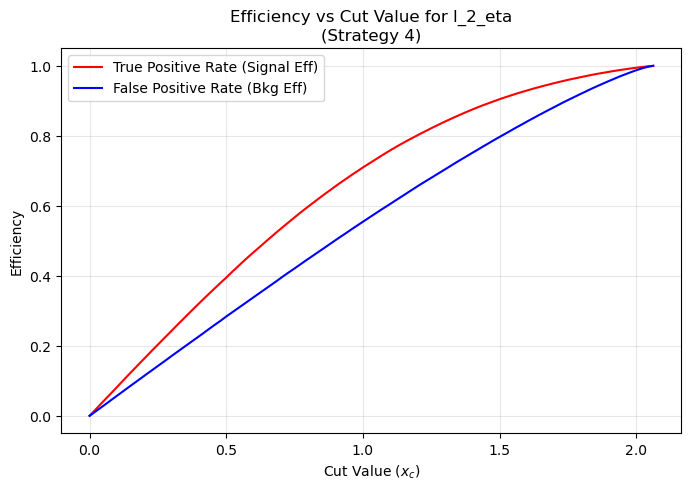

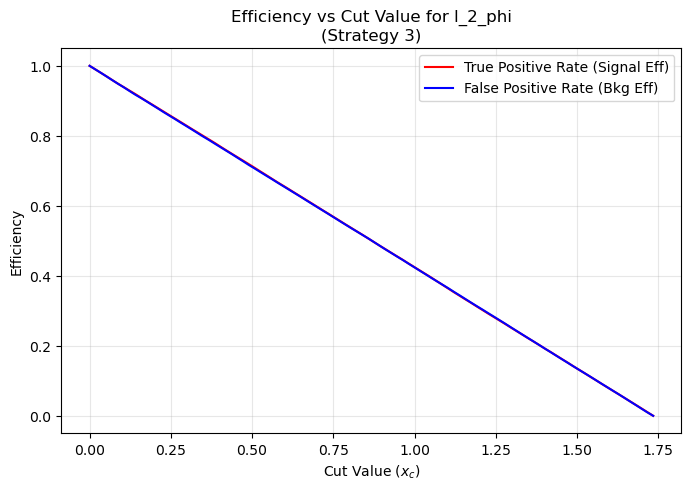

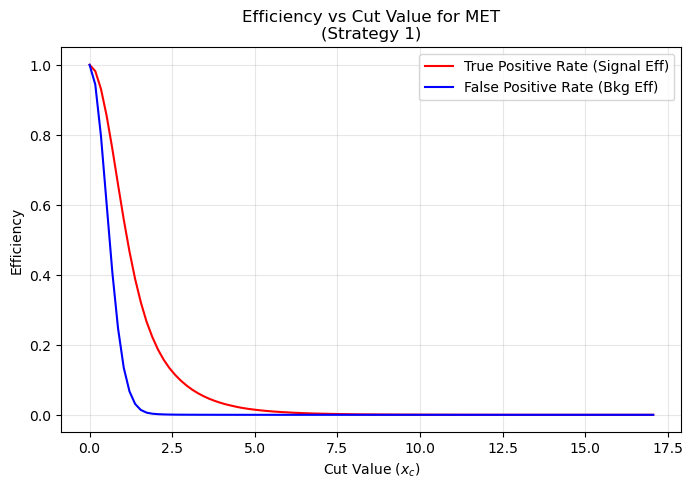

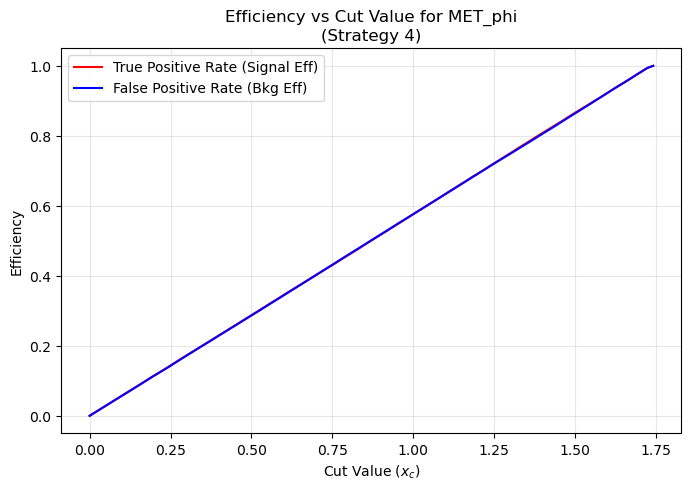

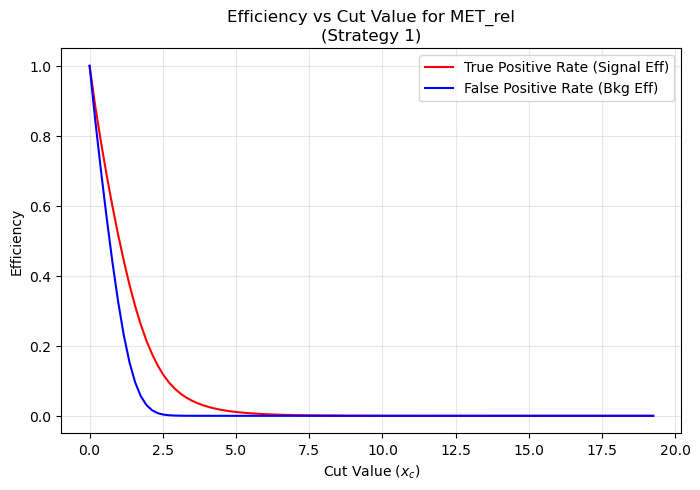

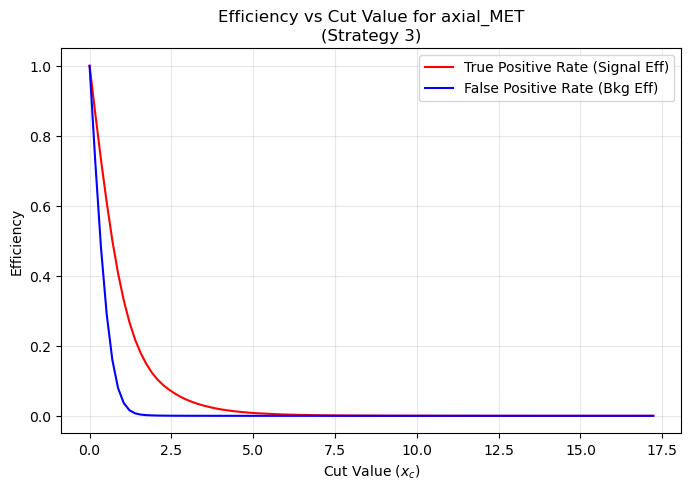

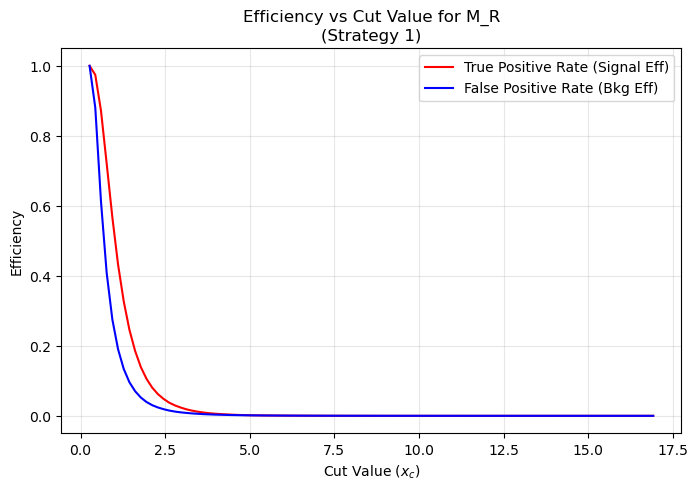

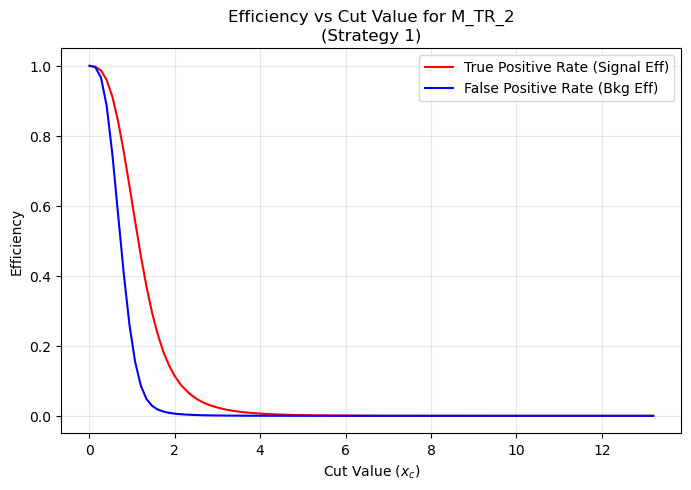

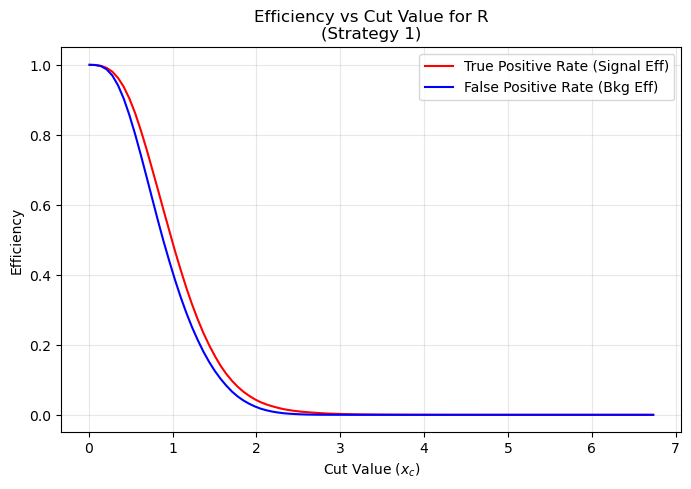

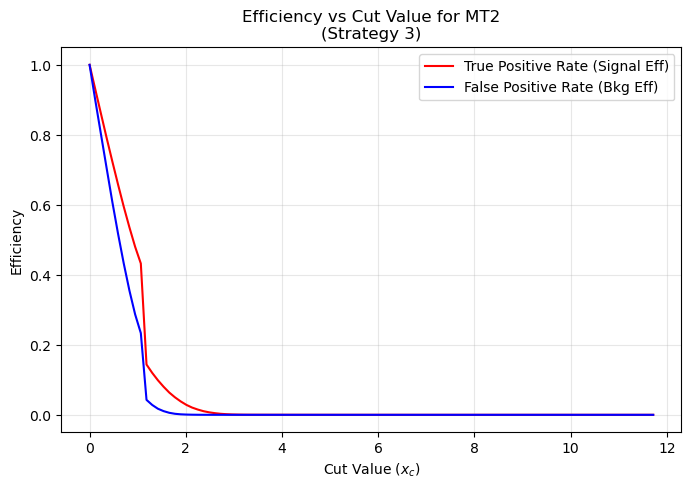

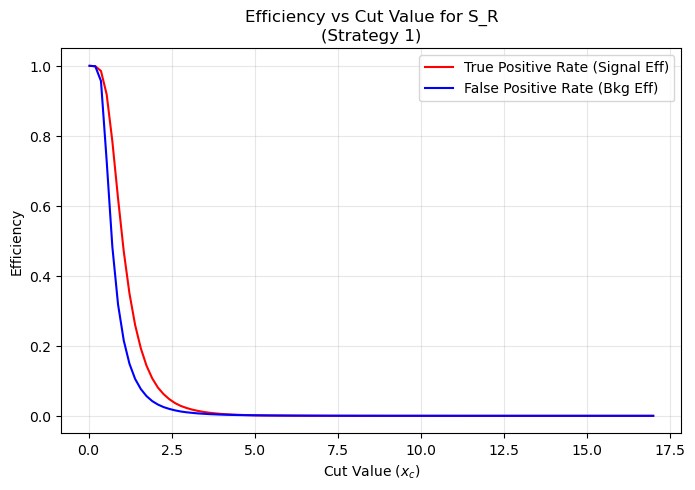

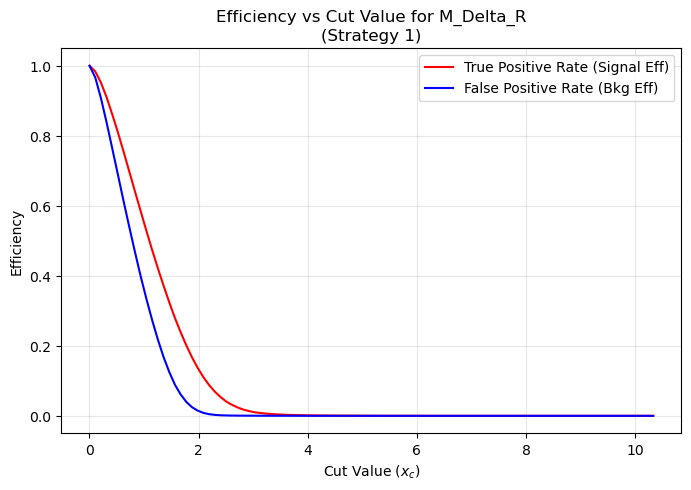

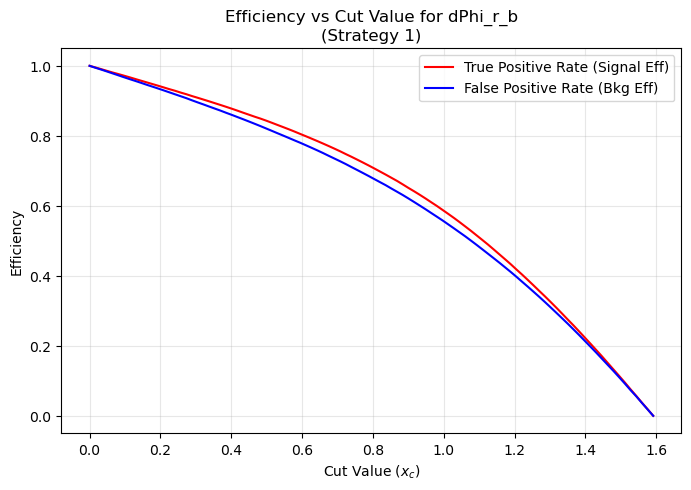

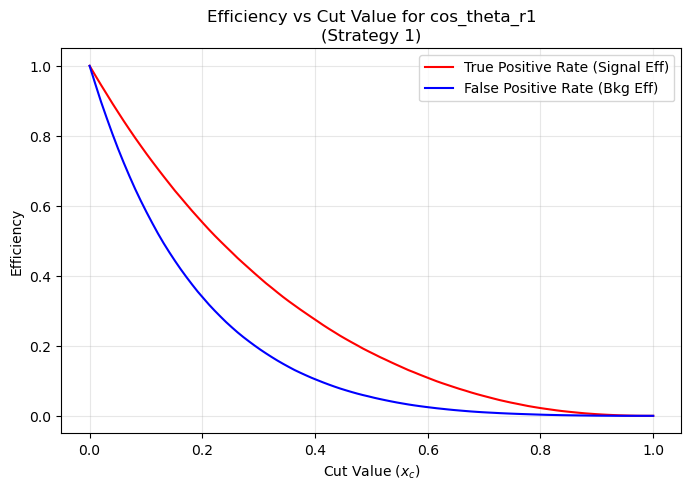

In [82]:
#exercise 5.2
import matplotlib.pyplot as plt
import numpy as np

#i will store results here to use in exercise5.3
tpr_dict={}
fpr_dict={}
xc_dict={}

#loop through every observable
for var in all_observables:
    #get the specific signal and background data for this variable
    x_sig=np.array(df_sig[var])
    x_bkg=np.array(df_bkg[var])
    
    #get the best strategy decided on in exercise5.1
    strategy=best_strategy_dict[var]
    mu=mu_dict[var] #only used for strategies 3 and 4
    
    #creating 100 test cut values xc to plot
    #i am using the same helper function from previous code
    xc_scan=get_scan_values(df[var],strategy,n_points=100,mu=mu)
    
    tpr_list=[]
    fpr_list=[]
    
    #for every cut value,calculating the efficiencies
    for xc in xc_scan:
        #calculate TPR: what % of good events did keep
        tpr=efficiency(x_sig,xc,strategy,mu=mu)
        #calculate FPR: what % of bad events accidentally got in
        fpr=efficiency(x_bkg,xc,strategy,mu=mu)
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    
    #storing these for the next exercise
    tpr_dict[var]=np.array(tpr_list)
    fpr_dict[var]=np.array(fpr_list)
    xc_dict[var]=xc_scan

    #plotting the results
    plt.figure(figsize=(8,5))
    plt.plot(xc_scan,tpr_list,color='red',label='True Positive Rate (Signal Eff)')
    plt.plot(xc_scan,fpr_list,color='blue',label='False Positive Rate (Bkg Eff)')
    
    plt.title(f"Efficiency vs Cut Value for {var}\n(Strategy {strategy})")
    plt.xlabel(f"Cut Value ($x_c$)")
    plt.ylabel("Efficiency")
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.show()

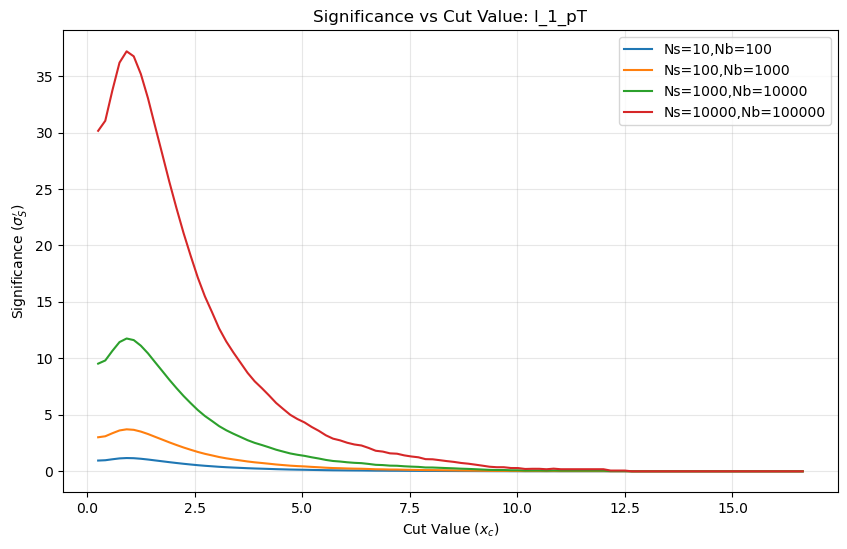

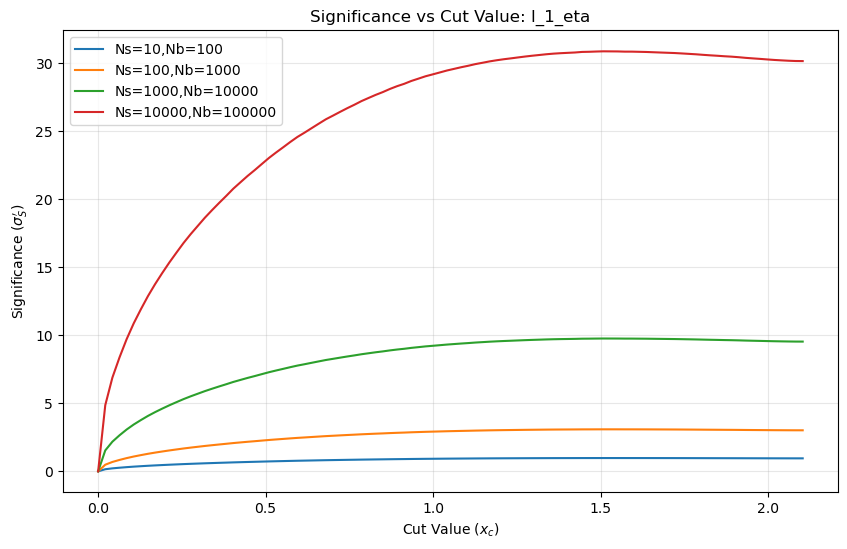

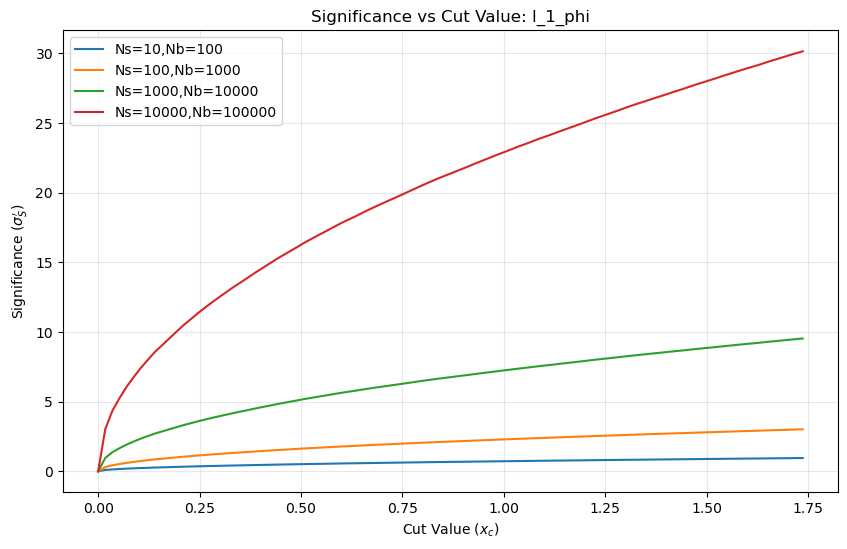

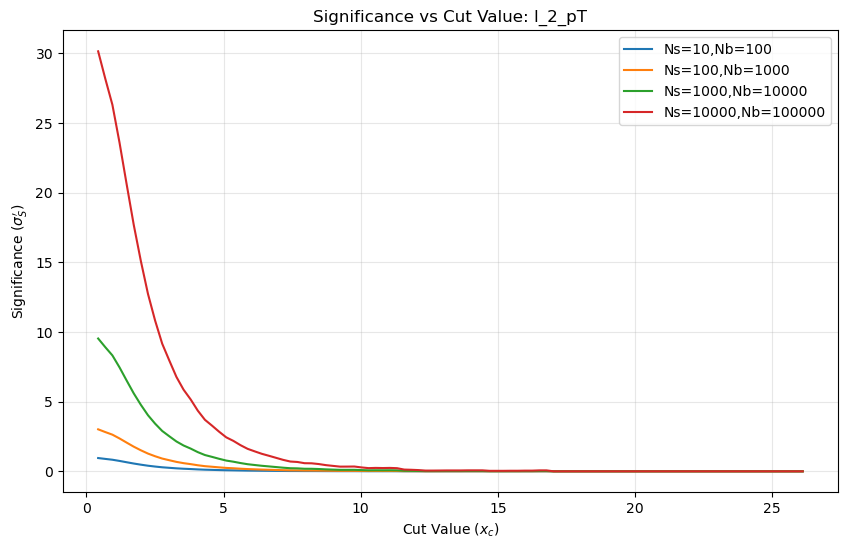

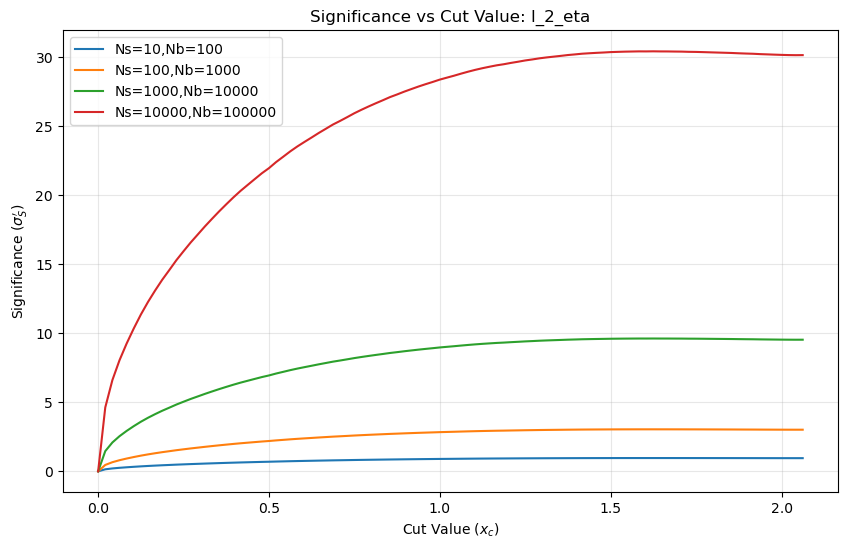

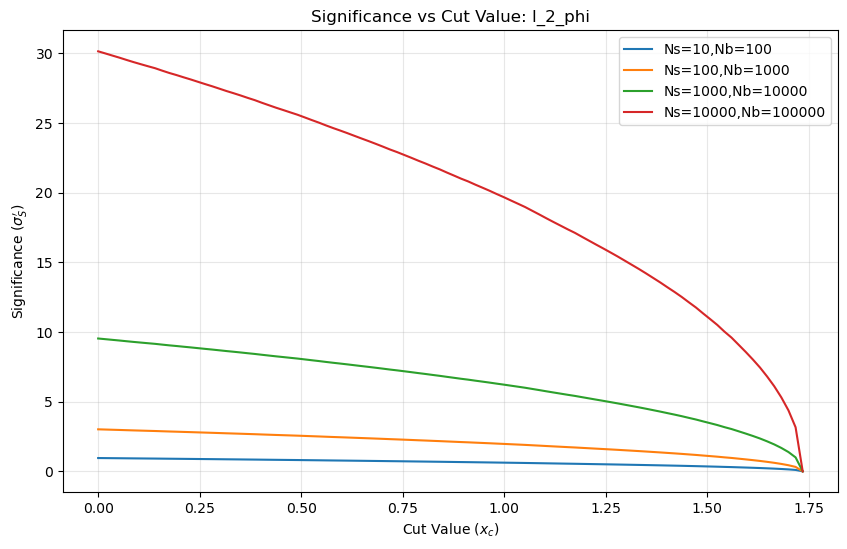

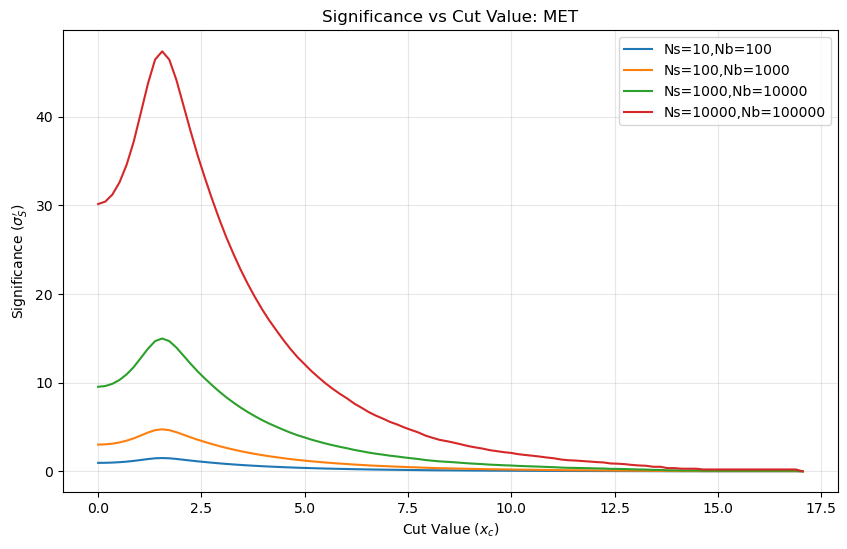

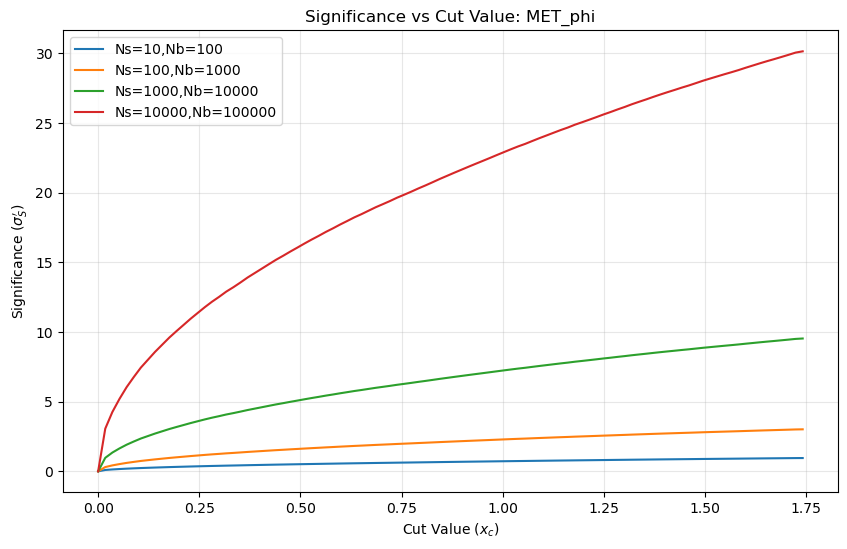

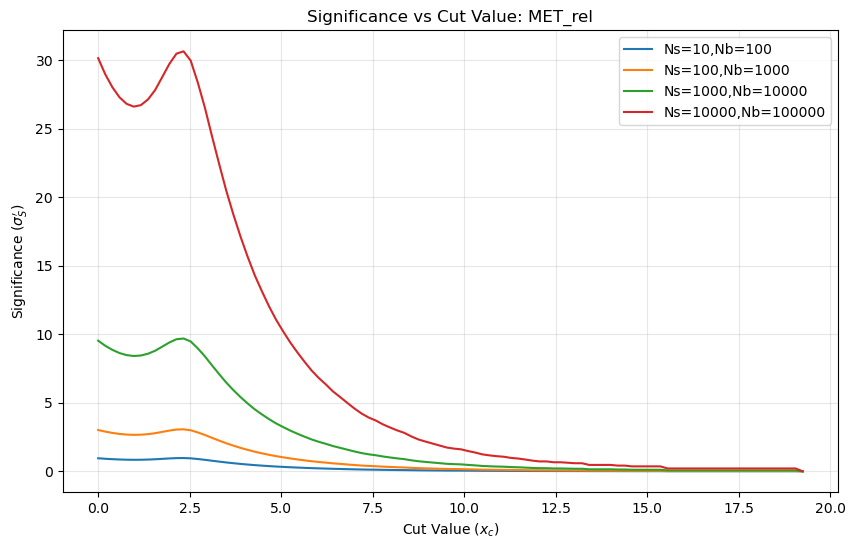

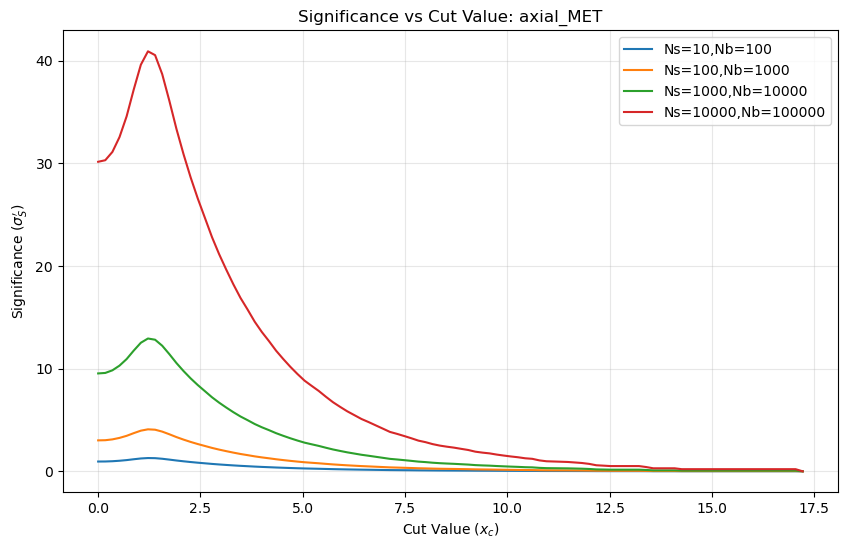

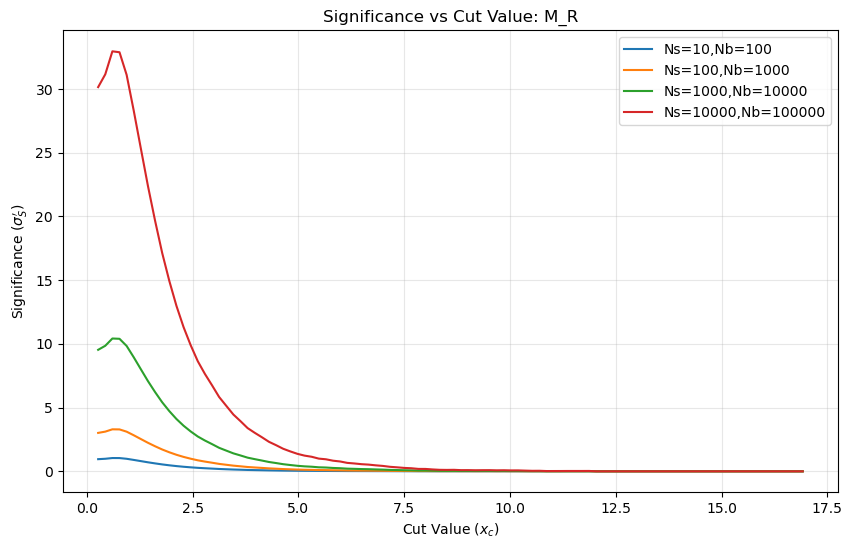

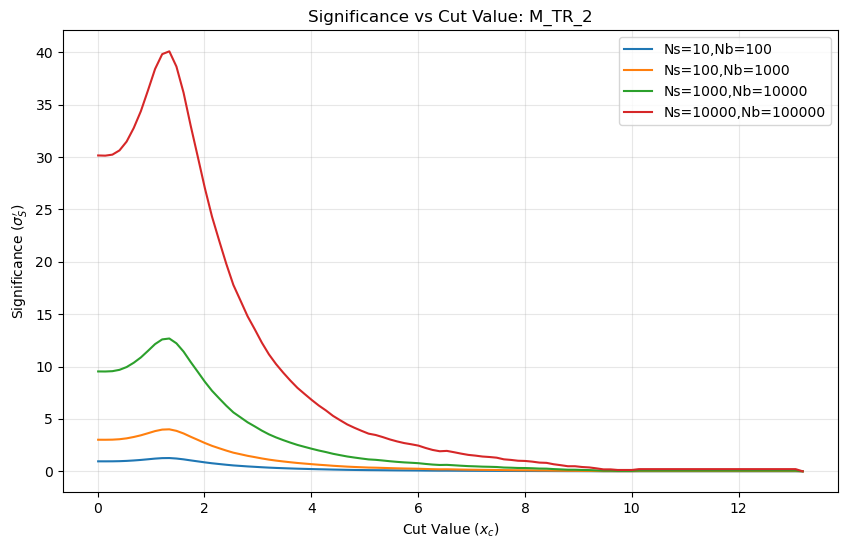

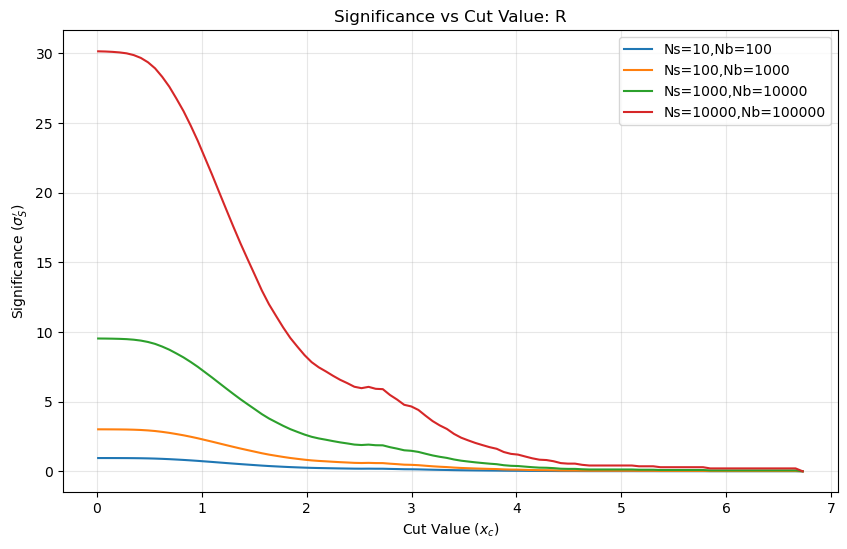

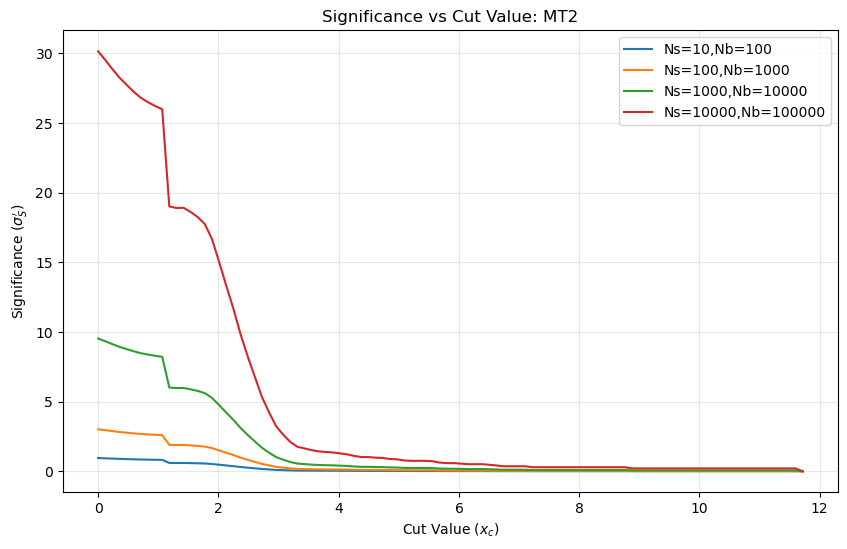

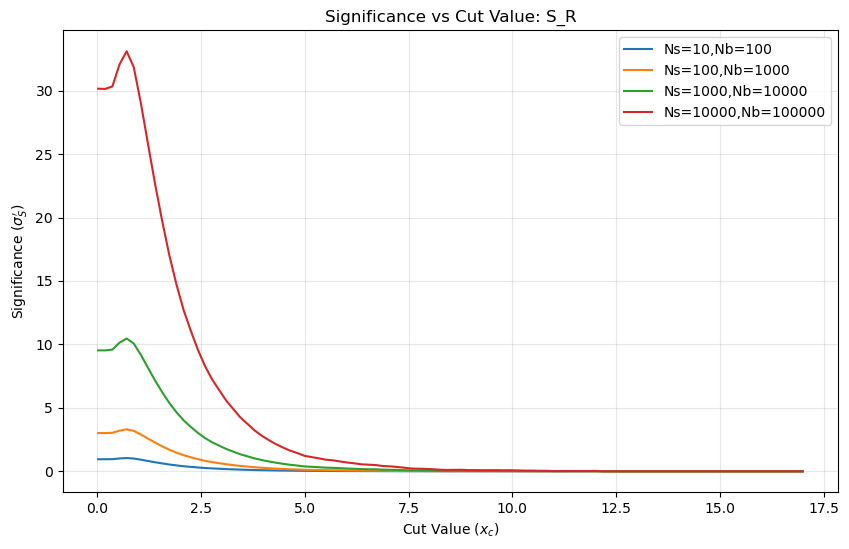

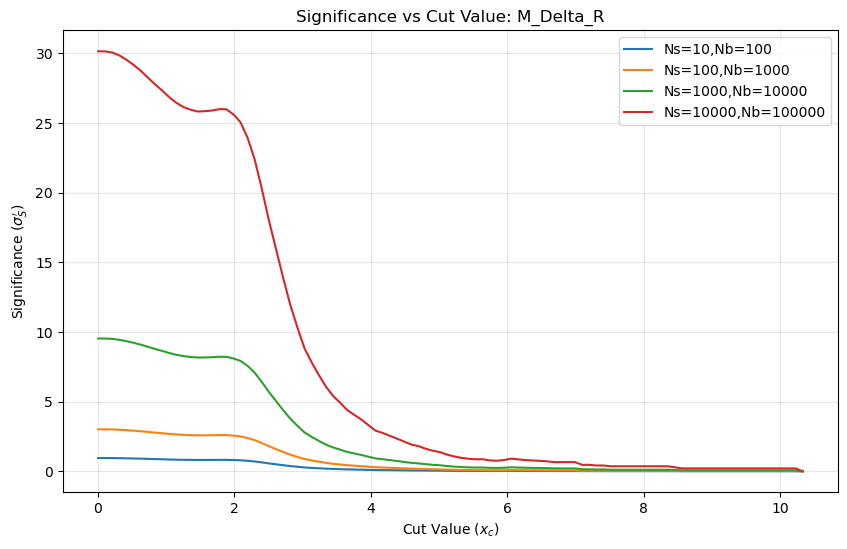

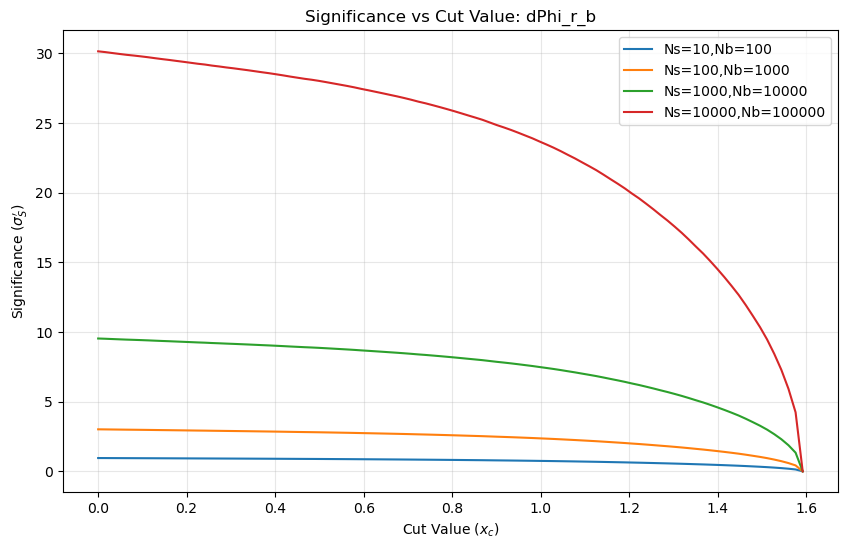

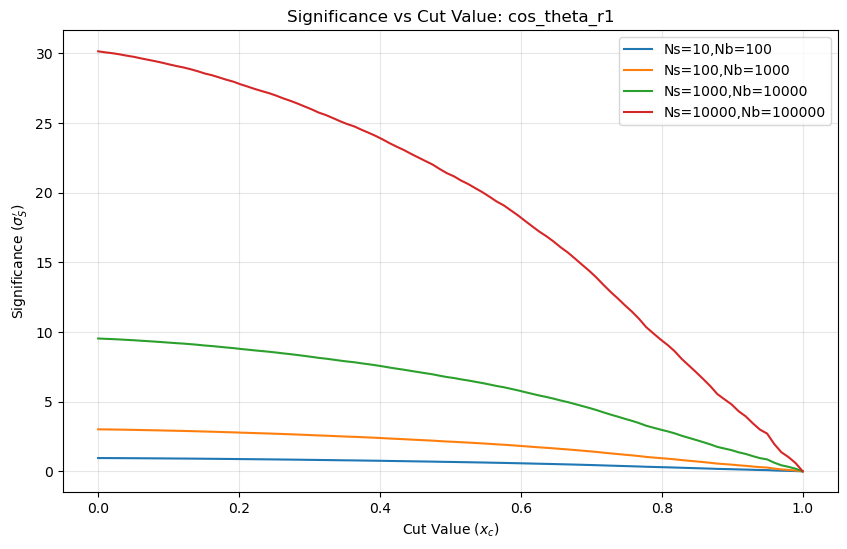

In [83]:
#exercise 5.3
import matplotlib.pyplot as plt
import numpy as np

#defining the 4 scenarios from the exercise
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]

#will loop through each observable again
for var in all_observables:
    plt.figure(figsize=(10,6))
    
    #getting the data i saved from exercise 5.2
    eps_s=tpr_dict[var]  #signal efficiency (TPR)
    eps_b=fpr_dict[var]  #background efficiency (FPR)
    xc_scan=xc_dict[var] #the cut values we tested
    
    #testingt each of the 4 scenarios
    for ns_total,nb_total in scenarios:
        
        #calculating how many events pass the cut in this scenario
        ns_prime=eps_s*ns_total
        nb_prime=eps_b*nb_total
        
        #calculating the significance(sigma_s)
        #adding a tiny number(1e-10) to the denominator to prevent divide by zero errors
        significance=ns_prime/np.sqrt(ns_prime+nb_prime+1e-10)
        
        #plotting the significance curve for this scenario
        label_text=f"Ns={ns_total},Nb={nb_total}"
        plt.plot(xc_scan,significance,label=label_text)
        
    plt.title(f"Significance vs Cut Value: {var}")
    plt.xlabel(f"Cut Value ($x_c$)")
    plt.ylabel(r"Significance ($\sigma_S'$)")
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [144]:
#exercise 6.1
import numpy as np

#defining the scenarios (Ns, Nb)
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]
all_vars=VarNames[1:]

#this dictionary will store winning cut settings for the next step
best_cuts_dict={}

print("Exercise 6.1:Identifying Optimal Selections")

for ns_tot,nb_tot in scenarios:
    results=[]
    
    for var in all_vars:
        #getting the best strategy for this variable (from Exercise 5.1)
        strat=best_strategy_dict[var]
        mu=mu_dict[var]
        
        #scanning 100 possible cut values (xc)
        xc_scan=get_scan_values(df[var],strat,n_points=100,mu=mu)
        
        best_sig_for_var=-1
        best_xc_for_var=0
        
        for xc in xc_scan:
            #calculating how many signal and background events pass
            eps_s=efficiency(df_sig[var],xc,strat,mu=mu)
            eps_b=efficiency(df_bkg[var],xc,strat,mu=mu)
            
            ns_p=eps_s*ns_tot
            nb_p=eps_b*nb_tot
            
            #calculate Significance: S/sqrt(S+B)
            sig=ns_p/np.sqrt(ns_p+nb_p+1e-10)
            
            if sig>best_sig_for_var:
                best_sig_for_var=sig
                best_xc_for_var=xc
        
        results.append((var,strat,best_xc_for_var,best_sig_for_var))
    
    #sorting by significance (index 3) and keeping the top 3 variables
    results.sort(key=lambda x:x[3],reverse=True)
    top_3=results[:3]
    best_cuts_dict[(ns_tot, nb_tot)]=top_3
    
    print(f"\nScenario Ns={ns_tot}:")
    for v, s, xc, sig in top_3:
        print(f"  - {v}: Use Strategy {s} at xc={xc:.3f} (Sigma={sig:.2f})")

Exercise 6.1:Identifying Optimal Selections

Scenario Ns=10:
  - MET: Use Strategy 1 at xc=1.551 (Sigma=1.50)
  - axial_MET: Use Strategy 3 at xc=1.218 (Sigma=1.29)
  - M_TR_2: Use Strategy 1 at xc=1.342 (Sigma=1.27)

Scenario Ns=100:
  - MET: Use Strategy 1 at xc=1.551 (Sigma=4.74)
  - axial_MET: Use Strategy 3 at xc=1.218 (Sigma=4.09)
  - M_TR_2: Use Strategy 1 at xc=1.342 (Sigma=4.01)

Scenario Ns=1000:
  - MET: Use Strategy 1 at xc=1.551 (Sigma=14.98)
  - axial_MET: Use Strategy 3 at xc=1.218 (Sigma=12.94)
  - M_TR_2: Use Strategy 1 at xc=1.342 (Sigma=12.68)

Scenario Ns=10000:
  - MET: Use Strategy 1 at xc=1.551 (Sigma=47.38)
  - axial_MET: Use Strategy 3 at xc=1.218 (Sigma=40.91)
  - M_TR_2: Use Strategy 1 at xc=1.342 (Sigma=40.09)


In [145]:
#exercise 6.2
import tabulate
from IPython.display import HTML, display

#calling this a Cut-Flow because watching the data flow through different filters
print("\n Exercise 6.2: Generating Discovery Cut-Flow Tables ")

#looping through each of our 4 scenarios (from tiny 10 signal events to 10,000)
for (ns_tot, nb_tot),top_3 in best_cuts_dict.items():
    
    #resetting the current scenario
    #starting with 100% of our signal(cur_eps_s) and 100% of our background(cur_eps_b)
    #1.0 is the decimal form of 100%
    cur_eps_s=1.0 
    cur_eps_b=1.0
    
    #creating an empty list to hold the rows of our final table
    table_rows=[]
    
    #calculating the starting points
    #this shows us how hard it would be to find the signal if we didn't use any filters
    sig_init=ns_tot/np.sqrt(ns_tot+nb_tot)
    
    #adding the first row:[Step Name,Sig %,Bkg %,Current Signal Count,Current Bkg Count,Significance]
    table_rows.append(["Initial Data (No Cuts)",1.0,1.0,ns_tot,nb_tot,round(sig_init,3)])
    
    #applying for top 3 filters one by one
    #using the top_3 variables identified in exercise 6.1 for this specific scenario
    for var,strat,xc, _ in top_3:
        mu=mu_dict[var] #only needed if the strategy uses a mean (like strategy 3 or 4)
        
        #calculating the survival rate (efficiency) for just this specific filter
        #it asks: out of the events that were there, what % passed thisspecific test?
        s_eff_step=efficiency(df_sig[var],xc,strat,mu=mu)
        b_eff_step=efficiency(df_bkg[var],xc,strat,mu=mu)
        
#cumulative math
#since an event has to pass all cuts to be kept,so multiplying the efficiencies.
        #example: if cut 1 keeps 50% and cut 2 keeps 50%, only 25% of the original data remains.
        cur_eps_s*=s_eff_step
        cur_eps_b*=b_eff_step
        
        #now calculating the physical number of signal(Ns) and background(Nb) events left
        ns_p=cur_eps_s*ns_tot
        nb_p=cur_eps_b*nb_tot
        
        #calculating significance
        #using the formula: S/sqrt(S+B)
        #i want this number to get bigger after every cut. 
        #even if i lose some signal, we want to lose way more background.
        sig_p=ns_p/np.sqrt(ns_p+nb_p+1e-10)
        
        #adding the results of this cut to our table data
        table_rows.append([
            f"Add Cut: {var}",      #the variable name (e.g., MET or MT2)
            round(cur_eps_s, 4),    #running total of signal efficiency
            round(cur_eps_b, 4),    #running total of background efficiency
            round(ns_p, 1),         #how many signal events are still in the detector
            round(nb_p, 1),         #how many background events are still in the detector
            round(sig_p, 3)         #the updated significance (Discovery Power)
        ])
    
#printing
    headers=["Selection Step","Total eps_S","Total eps_B","N' Signal","N' Bkg","Significance"]
    print(f"\nResults for Scenario: Ns={ns_tot}, Nb={nb_tot}")
    
    #this turns list of rows into a nice looking HTML table for the report
    display(HTML(tabulate.tabulate(table_rows,headers=headers,tablefmt='html')))


 Exercise 6.2: Generating Discovery Cut-Flow Tables 

Results for Scenario: Ns=10, Nb=100


Selection Step,Total eps_S,Total eps_B,N' Signal,N' Bkg,Significance
Initial Data (No Cuts),1,1,10,100,0.953
Add Cut: MET,0.3215,0.0139,3.2,1.4,1.498
Add Cut: axial_MET,0.086,0.0002,0.9,0,0.915
Add Cut: M_TR_2,0.0317,0,0.3,0,0.562



Results for Scenario: Ns=100, Nb=1000


Selection Step,Total eps_S,Total eps_B,N' Signal,N' Bkg,Significance
Initial Data (No Cuts),1,1,100,1000,3.015
Add Cut: MET,0.3215,0.0139,32.2,13.9,4.738
Add Cut: axial_MET,0.086,0.0002,8.6,0.2,2.895
Add Cut: M_TR_2,0.0317,0,3.2,0,1.778



Results for Scenario: Ns=1000, Nb=10000


Selection Step,Total eps_S,Total eps_B,N' Signal,N' Bkg,Significance
Initial Data (No Cuts),1,1,1000,10000,9.535
Add Cut: MET,0.3215,0.0139,321.5,139.1,14.981
Add Cut: axial_MET,0.086,0.0002,86,2.2,9.154
Add Cut: M_TR_2,0.0317,0,31.7,0.1,5.622



Results for Scenario: Ns=10000, Nb=100000


Selection Step,Total eps_S,Total eps_B,N' Signal,N' Bkg,Significance
Initial Data (No Cuts),1,1,10000,100000,30.151
Add Cut: MET,0.3215,0.0139,3215.1,1390.6,47.375
Add Cut: axial_MET,0.086,0.0002,859.6,22.2,28.947
Add Cut: M_TR_2,0.0317,0,317.2,1.1,17.78


In [146]:
#exercise 6.3
def get_significance_curve(dataframe,var,strategy,N_S_total,N_B_total,n_points=100):
    #this function scans through different cut values(xc) and calculates the significance for each one so we can find the best peak.
    #splitting the data into signal and background groups
    sig_data=dataframe[dataframe['signal']==1][var].values
    bkg_data=dataframe[dataframe['signal']==0][var].values
    mu=mu_dict[var]
    
    #getting 100 possible cut values (xc) to test
    xc_scan=get_scan_values(dataframe[var],strategy,n_points=n_points,mu=mu)
    
    sig_results=[]
    
    for xc in xc_scan:
        #calculating what percentage of events survive this cut
        #using the efficiency function
        eps_s=efficiency(sig_data,xc,strategy,mu=mu)
        eps_b=efficiency(bkg_data,xc,strategy,mu=mu)
        
        #scaling these percentages up to the real scenario numbers
        ns_prime=eps_s*N_S_total
        nb_prime=eps_b*N_B_total
        
        #calculating significance: S/sqrt(S+B)
        #adding a tiny number (1e-10) to prevent divide by zero errors
        significance=ns_prime/np.sqrt(ns_prime+nb_prime+1e-10)
        sig_results.append(significance)
        
    return xc_scan,sig_results

In [147]:
#useing Scenario 4 (10k/100k) because it's the easiest to see changes in
var_a,var_b = "MET","MT2"
ns,nb=10000,100000
#cASE 1:ordee A -> B (Cut on MET first, then optimize MT2)
#apply the best cut for MET
xc_a=best_cuts_dict[(ns, nb)][0][2] 
strat_a=best_strategy_dict[var_a]
df_survivors_a=df[pass_selection(df[var_a],xc_a,strat_a,mu=mu_dict[var_a])]

#find the new best cut for MT2 based on those survivors
xc_scan_b,sig_scan_b=get_significance_curve(df_survivors_a,var_b,best_strategy_dict[var_b],ns,nb)
best_xc_b_after_a=xc_scan_b[np.argmax(sig_scan_b)]
max_sig_order_a=np.max(sig_scan_b)
#case 2: order B -> A (Cut on MT2 first,then optimize MET)

#applying the best cut for MT2
xc_b=best_cuts_dict[(ns, nb)][1][2] 
strat_b=best_strategy_dict[var_b]
df_survivors_b=df[pass_selection(df[var_b],xc_b,strat_b,mu=mu_dict[var_b])]

#finding the new best cut for MET based on those survivors
xc_scan_a,sig_scan_a=get_significance_curve(df_survivors_b,var_a,best_strategy_dict[var_a],ns,nb)
best_xc_a_after_b=xc_scan_a[np.argmax(sig_scan_a)]
max_sig_order_b=np.max(sig_scan_a)
print(f" Comparison of Selection Order ")
print(f"Order {var_a} ->{var_b}: Final Significance={max_sig_order_a:.4f}")
print(f"Order {var_b} ->{var_a}: Final Significance={max_sig_order_b:.4f}")

 Comparison of Selection Order 
Order MET ->MT2: Final Significance=30.1507
Order MT2 ->MET: Final Significance=47.3616


In [131]:
#Because variables like MET and MT2 are correlated, they share information. 
#To get the highest discovery power (Significance), we cannot treat them as independent.
#We must apply one cut, see what data is left, and then find the new 'best' spot for the second cut. 
#The fact that changing the order changes the result proves that these variables are mathematically linked.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



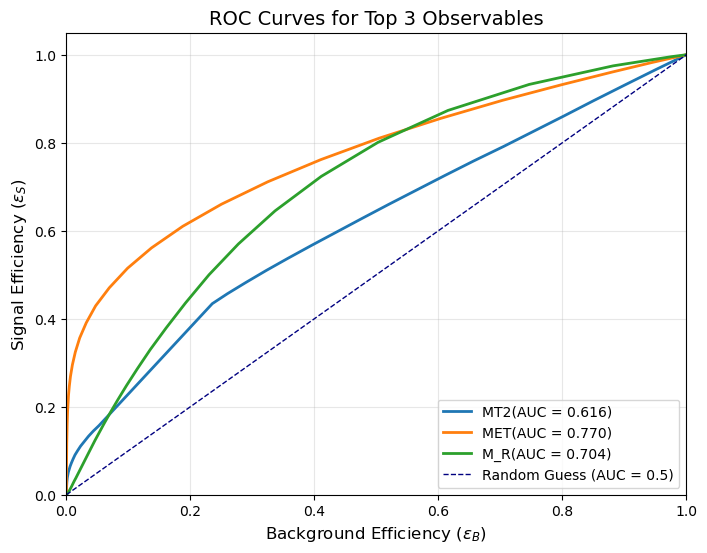

In [148]:
#exercise 7.1
import matplotlib.pyplot as plt
import numpy as np

#identifying the top 3 variables from exercise 6.1
#taking the winners from the 10k/100k scenario

top_3_vars=top_3_vars=["MT2", "MET", "M_R"]

plt.figure(figsize=(8,6))

for var in top_3_vars:
    #getting signal and background data
    sig_vals=df_sig[var].values
    bkg_vals=df_bkg[var].values
    strat=best_strategy_dict[var]
    mu=mu_dict[var]
    
    #generating a scan of efficiencies
    #using 200 points to make the curve smooth
    xc_scan=get_scan_values(df[var],strat,n_points=200,mu=mu)
    
    eps_s_list=[]
    eps_b_list=[]
    
    for xc in xc_scan:
        eps_s_list.append(efficiency(sig_vals,xc,strat,mu=mu))
        eps_b_list.append(efficiency(bkg_vals,xc,strat,mu=mu))
    
    #manually AUC Calculation (Trapezoidal Rule)
    #sorting the background efficiency (x-axis) to ensure the integration works
    x=np.array(eps_b_list)
    y=np.array(eps_s_list)
    
    #sorting points by x-coordinate to ensure a clean path for the area calculation
    sort_idx=np.argsort(x)
    x_sorted=x[sort_idx]
    y_sorted=y[sort_idx]
    
    #calculating area: np.trapz computes the area under y with respect to x
    manual_auc=np.trapz(y_sorted, x_sorted)
    
    #plotting
    plt.plot(x_sorted,y_sorted,label=rf'{var}(AUC = {abs(manual_auc):.3f})',lw=2)

#adding the random Guess reference line
plt.plot([0, 1],[0, 1],color='navy',lw=1,linestyle='--',label='Random Guess (AUC = 0.5)')

#formatting with r strings to avoid the LaTeX warnings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel(r'Background Efficiency ($\epsilon_B$)',fontsize=12)
plt.ylabel(r'Signal Efficiency ($\epsilon_S$)',fontsize=12)
plt.title('ROC Curves for Top 3 Observables',fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

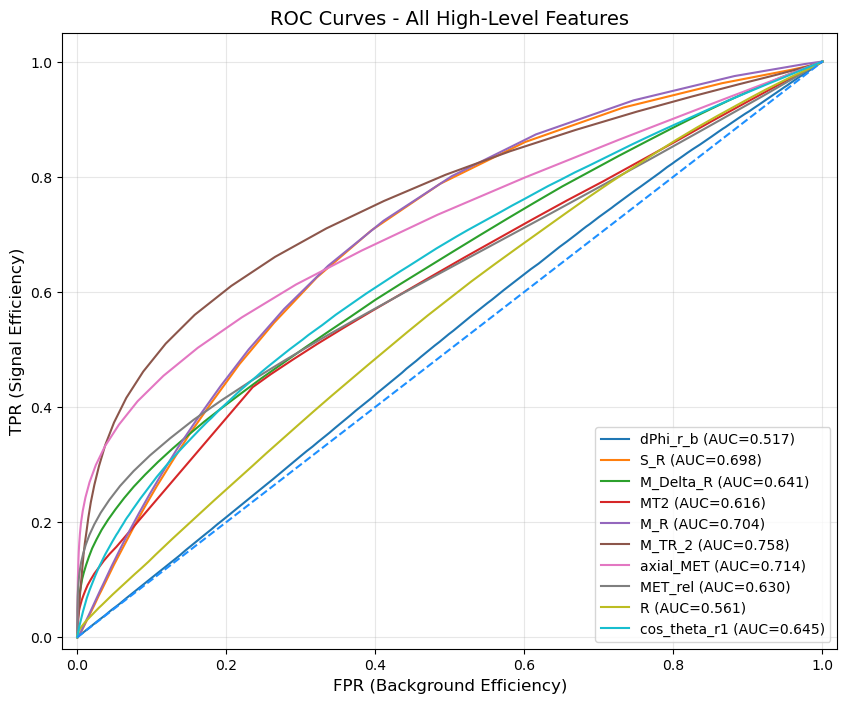

In [133]:
#exercise 7.2
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_curves(dataframe, variables, title="ROC Curves - All High-Level Features", selection_mask=None):
    """
    Creates a multi-variable ROC plot with AUC reporting in the legend.
    """
    # Apply selection mask if provided (for 'different conditions')
    working_df = dataframe if selection_mask is None else dataframe[selection_mask]
    
    # Split signal and background
    df_sig = working_df[working_df['signal'] == 1]
    df_bkg = working_df[working_df['signal'] == 0]
    
    if len(df_sig) == 0 or len(df_bkg) == 0:
        print("Error: No signal or background events in the current selection.")
        return

    plt.figure(figsize=(10, 8))
    
    for var in variables:
        # 1. Get strategy and data
        strat = best_strategy_dict[var]
        mu = mu_dict[var]
        sig_vals = df_sig[var].values
        bkg_vals = df_bkg[var].values
        
        # 2. Generate Scan
        xc_scan = get_scan_values(working_df[var], strat, n_points=200, mu=mu)
        
        tpr = [] # True Positive Rate (Signal Efficiency)
        fpr = [] # False Positive Rate (Background Efficiency)
        
        for xc in xc_scan:
            tpr.append(efficiency(sig_vals, xc, strat, mu=mu))
            fpr.append(efficiency(bkg_vals, xc, strat, mu=mu))
            
        # 3. Sort for AUC calculation (essential for np.trapz)
        fpr = np.array(fpr)
        tpr = np.array(tpr)
        idx = np.argsort(fpr)
        fpr_sorted = fpr[idx]
        tpr_sorted = tpr[idx]
        
        # 4. Calculate AUC using Trapezoidal Rule
        roc_auc = np.trapz(tpr_sorted, fpr_sorted)
        
        # 5. Plot
        plt.plot(fpr_sorted, tpr_sorted, label=f'{var} (AUC={abs(roc_auc):.3f})')

    # Reference diagonal line
    plt.plot([0, 1], [0, 1], color='dodgerblue', linestyle='--')
    
    # Formatting to match your image
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.05])
    plt.xlabel(r'FPR (Background Efficiency)', fontsize=12)
    plt.ylabel(r'TPR (Signal Efficiency)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", frameon=True)
    plt.grid(True, which='both', linestyle='-', alpha=0.3)
    plt.show()

# --- HOW TO RUN IT ---
# Define the list of observables you want to see (all of them)
high_level_features = ["dPhi_r_b", "S_R", "M_Delta_R", "MT2", "M_R", "M_TR_2", "axial_MET", "MET_rel", "R", "cos_theta_r1"]

# Call the function
plot_roc_curves(df, high_level_features)

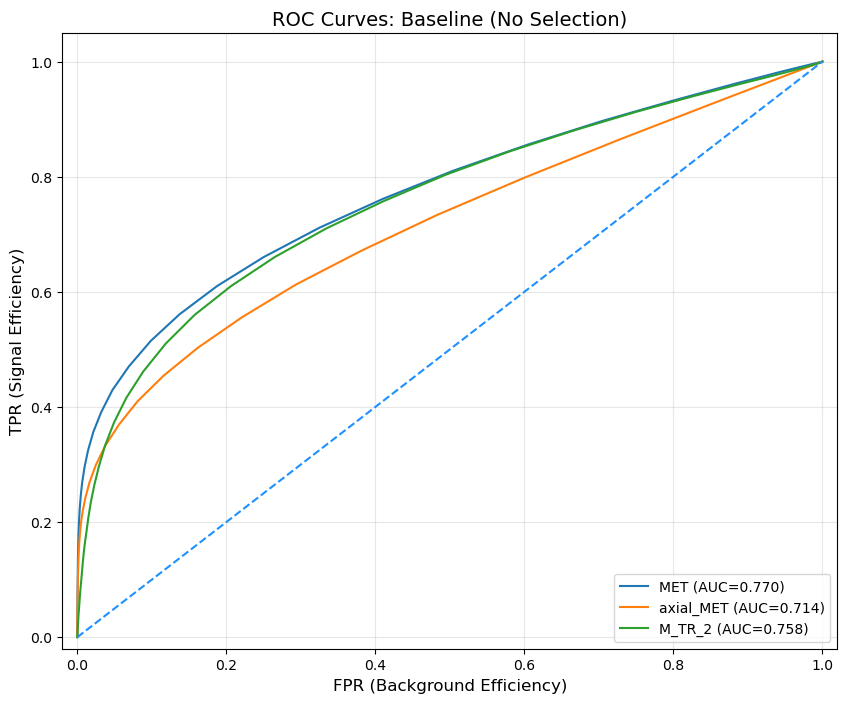

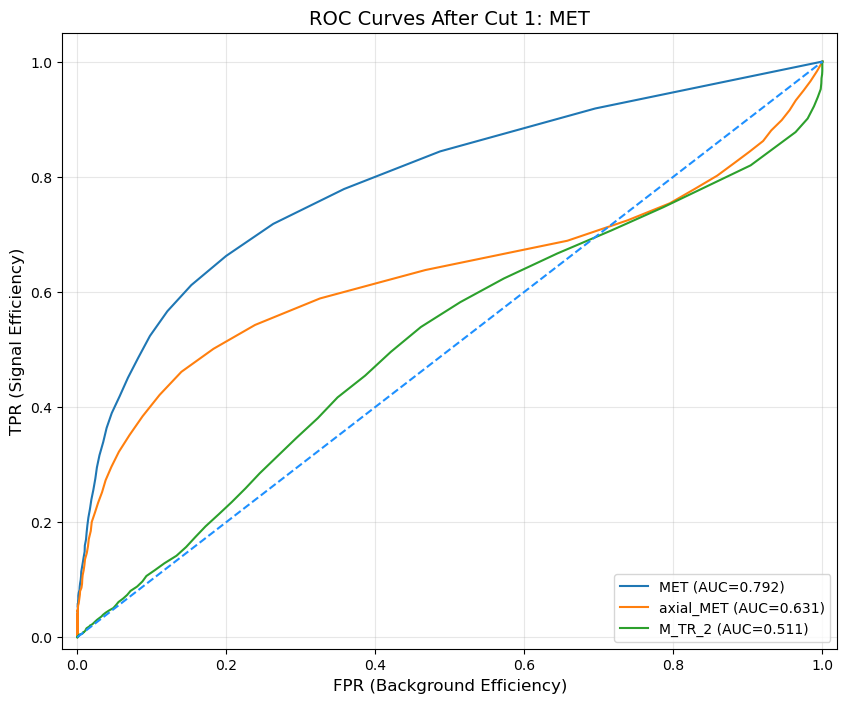

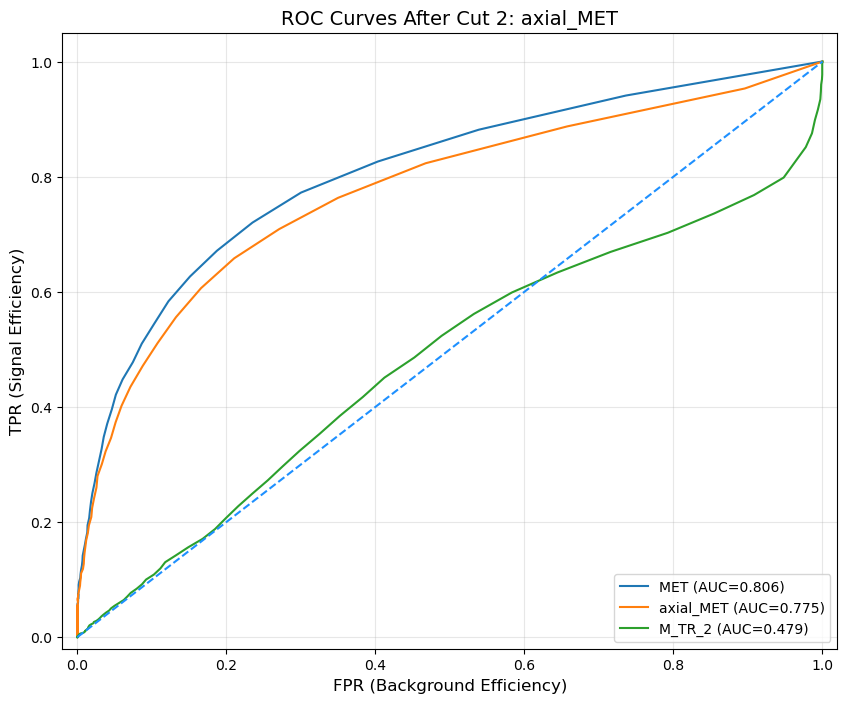

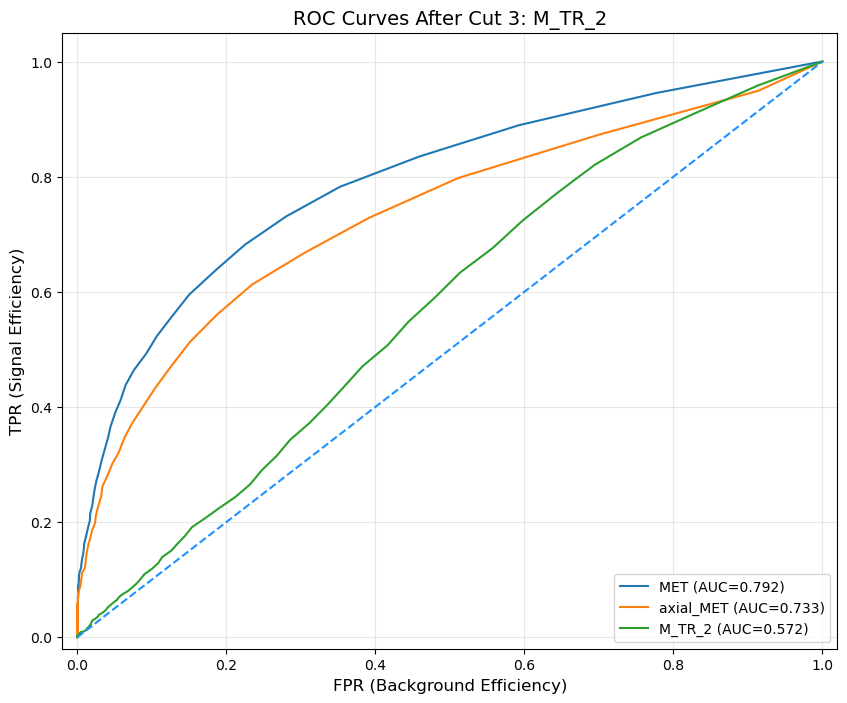

In [149]:
#exercise 7.3
#starting with the full dataset
df_current=df.copy()

#selecting the scenario to use (e.g the largest one for best statistics)
#using the (10000, 100000) scenario from your Exercise 6.1 results
scenario_key=(10000,100000)

if scenario_key not in best_cuts_dict:
    print(f"Error: {scenario_key} not found in best_cuts_dict")
else:
    #pulling the winning variables and their cut parameters
    #formatting from code:(var, strat, xc, sig)
    winning_cuts=best_cuts_dict[scenario_key]
    roc_observables=[item[0] for item in winning_cuts]

    #plotting the baseline ROC (Before any cuts)
    plot_roc_curves(df_current,roc_observables,title="ROC Curves: Baseline (No Selection)")

    #sequentially apply the cuts and re-plot
    for i,(var_name,strategy,x_c,sigma) in enumerate(winning_cuts):
        
        #retrieving the signal mean for the cut variable (mu)
        mu=mu_dict.get(var_name, 0)
        
        #applying the cut using your physics logic
        passed=pass_selection(df_current[var_name].values,x_c,strategy,mu=mu)
        df_current=df_current[passed].copy()
        
        #stopping if background is gone
        n_bkg=len(df_current[df_current['signal']==0])
        if n_bkg<10:
            print(f"Stopping at Cut {i+1} ({var_name}): Too few background events left.")
            break
            
        #plotting the updated ROC curves for the survivors
        plot_roc_curves(df_current,roc_observables, 
                        title=f"ROC Curves After Cut {i+1}: {var_name}")

 Order 1: MET then axial_MET


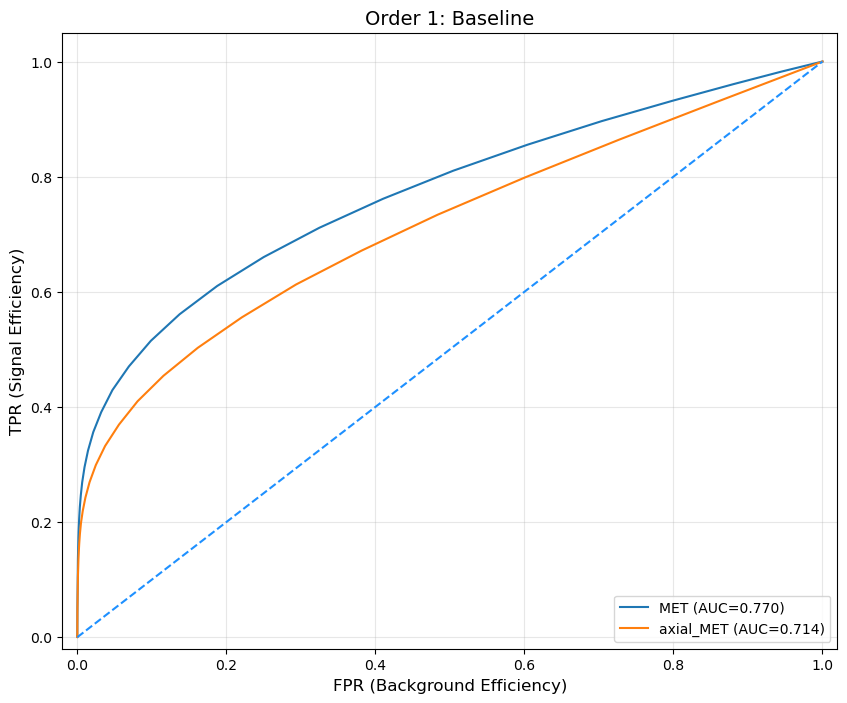

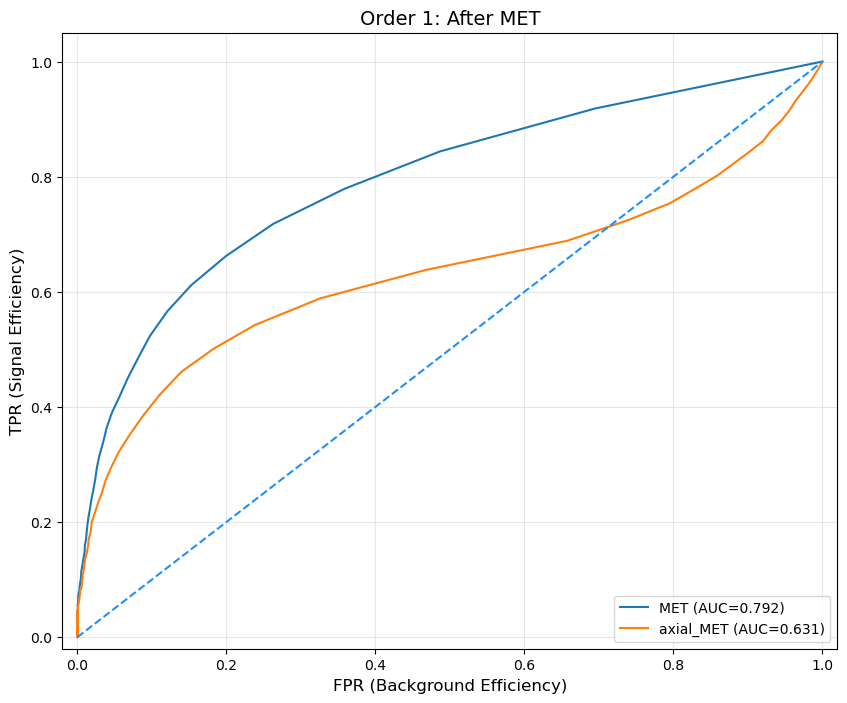

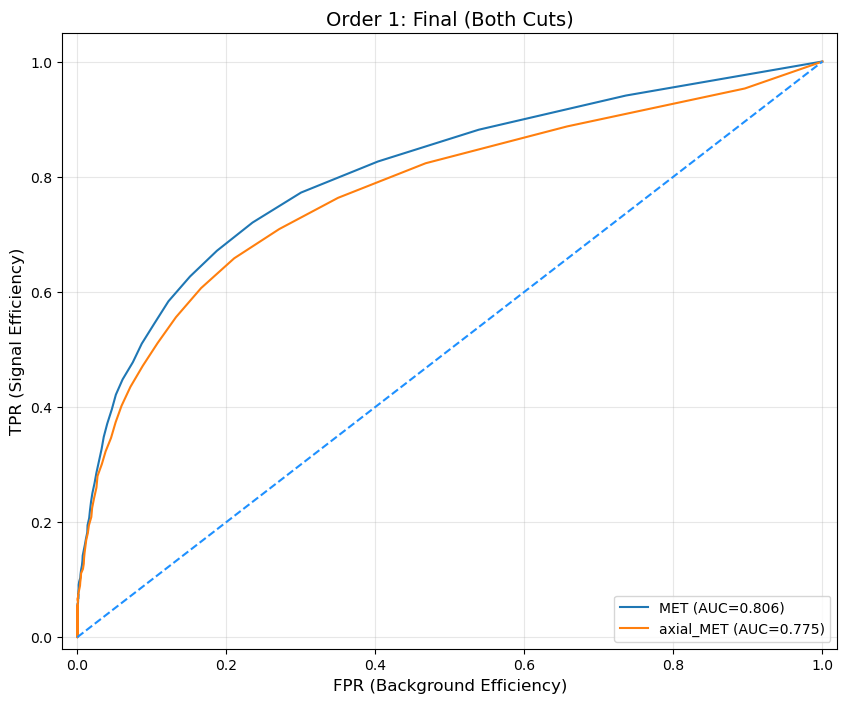


 Order 2: axial_MET then MET


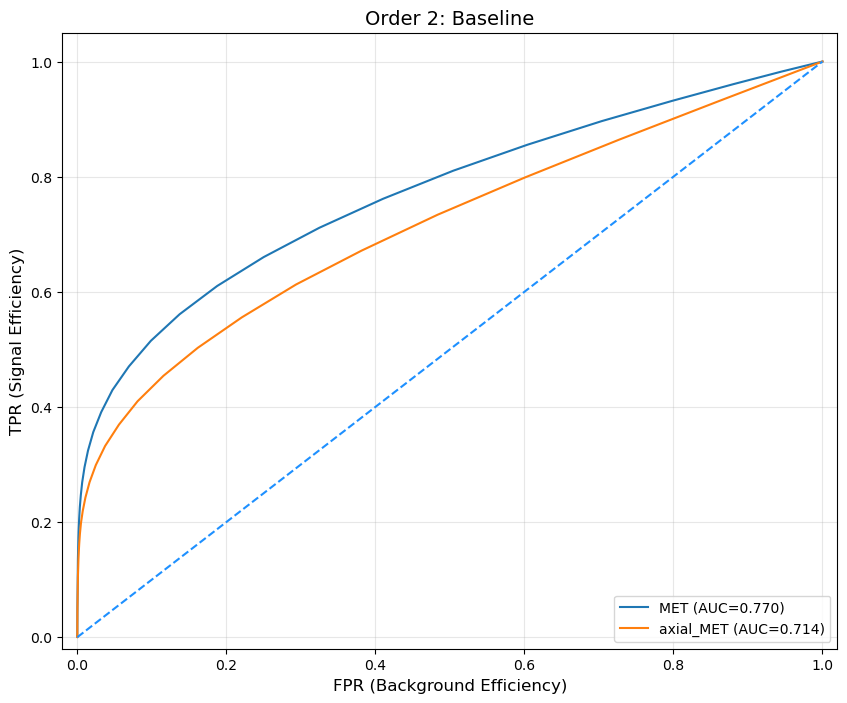

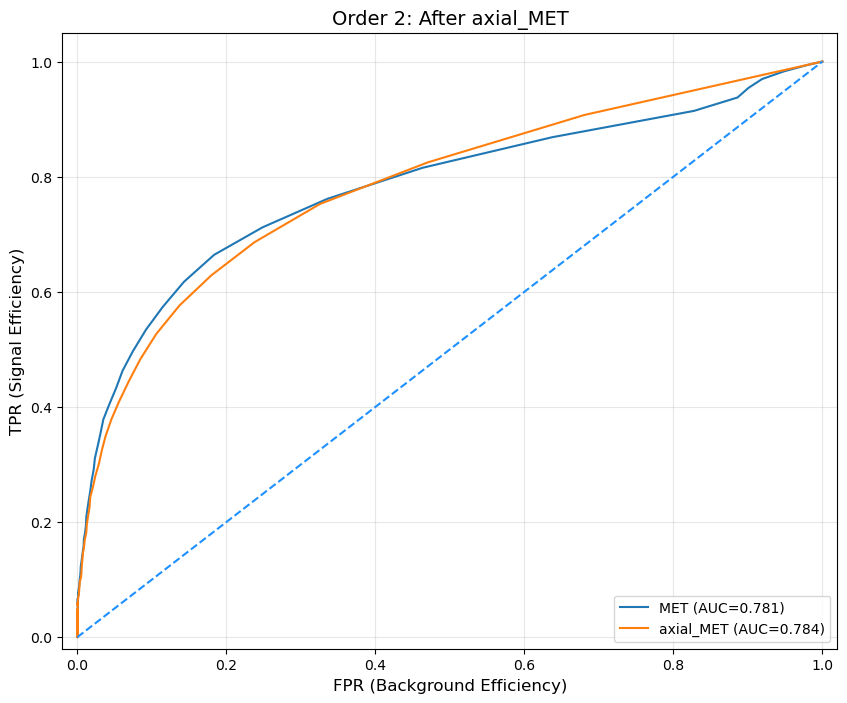

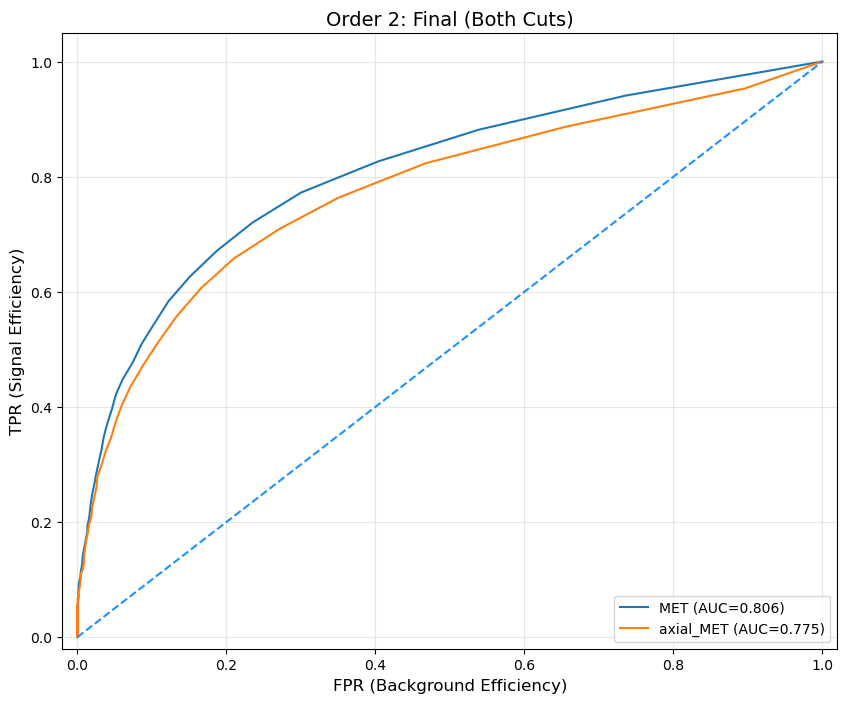

In [150]:
#exercise 7.4
#identifying the scenario and cuts to use
#using the (10000, 100000) scenario for the best visual clarity
scenario_key=(10000, 100000)
selected_cuts=best_cuts_dict[scenario_key]

#i will swap the first two cuts to demonstrate the order effect
first_cut_info=selected_cuts[0]   #(var, strategy, xc, sigma)
second_cut_info=selected_cuts[1] 

roc_observables=[first_cut_info[0], second_cut_info[0]]

#helper for the cuts
def apply_cut_for_roc(df_in,var,strategy,x_c):
    mu=mu_dict.get(var, 0)
    passed=pass_selection(df_in[var].values,x_c,strategy,mu=mu)
    return df_in[passed].copy()

#order 1: variable A then Variable B ---
print(f" Order 1: {first_cut_info[0]} then {second_cut_info[0]}")
df_o1=df.copy()
#step 1: baseline
plot_roc_curves(df_o1,roc_observables,title="Order 1: Baseline")
#step 2: applying first cut
df_o1=apply_cut_for_roc(df_o1, first_cut_info[0],first_cut_info[1],first_cut_info[2])
plot_roc_curves(df_o1,roc_observables,title=f"Order 1: After {first_cut_info[0]}")
#step 3: applying second cut
df_o1=apply_cut_for_roc(df_o1,second_cut_info[0],second_cut_info[1],second_cut_info[2])
plot_roc_curves(df_o1,roc_observables,title=f"Order 1: Final (Both Cuts)")

#order 2: variable B then Variable A
print(f"\n Order 2: {second_cut_info[0]} then {first_cut_info[0]}")
df_o2=df.copy()
#step 1:baseline(same as above)
plot_roc_curves(df_o2, roc_observables, title="Order 2: Baseline")
#step 2: applying second cut first
df_o2=apply_cut_for_roc(df_o2,second_cut_info[0],second_cut_info[1],second_cut_info[2])
plot_roc_curves(df_o2,roc_observables,title=f"Order 2: After {second_cut_info[0]}")
#step 3: applying first cut
df_o2=apply_cut_for_roc(df_o2,first_cut_info[0],first_cut_info[1],first_cut_info[2])
plot_roc_curves(df_o2,roc_observables,title=f"Order 2: Final (Both Cuts)")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [152]:
#exercise 8.1
import numpy as np

#selecting the features(observables)
#usually using a subset of top variables or all variables excluding signal
features=VarNames[1:] 

#extracting data as Numpy Matrices
#these will be shape (N_events, N_features)
X_sig=df[df['signal']==1][features].values
X_bkg=df[df['signal']==0][features].values

#computing mean vectors (m1 and m2)
#axis=0 calculates the average for each column (feature)
m1=np.mean(X_sig, axis=0) # mean vector for Signal
m2=np.mean(X_bkg, axis=0) # mean vector for Background

#computing between class scatter matrix (S_B)
#concept: i want to measure the separation between the two center points
#reshaping to column vectors (-1, 1) to perform an outer product
#(m2-m1) @(m2 - m1).T results in a (N_features x N_features) matrix
diff=(m2 - m1).reshape(-1, 1)
SB=diff @ diff.T

#computing within class scatter matrix (S_W)
#concept: iwant to measure the internal spread of each category.
#instead of a slow loop: sum((x-m) @ (x-m).T)
#using :(X_centered).T @ (X_centered) 
#this matrix multiplication automatically performs the sum of all outer products.

#centering the data by subtracting the mean from every row
X_sig_centered=X_sig-m1
X_bkg_centered=X_bkg-m2

#matrix multiplication effectively calculates the covariance within each class
SW=(X_sig_centered.T@X_sig_centered)+(X_bkg_centered.T @ X_bkg_centered)

#verification
print(f"Number of features used: {len(features)}")
print(f"SB Shape: {SB.shape} (Should be {len(features)}x{len(features)})")
print(f"SW Shape: {SW.shape} (Should be {len(features)}x{len(features)})")

#inspect a small slice of the matrices
print("\nTop-left corner of SW:")
print(SW[:3, :3])

Number of features used: 18
SB Shape: (18, 18) (Should be 18x18)
SW Shape: (18, 18) (Should be 18x18)

Top-left corner of SW:
[[ 1.97992314e+05 -2.55306615e+02 -1.97200507e+01]
 [-2.55306615e+02  5.02149623e+05 -4.28906989e+02]
 [-1.97200507e+01 -4.28906989e+02  5.01985584e+05]]


 Linear Coefficients (w) 
      l_1_pT: -0.0000
     l_1_eta: -0.0000
     l_1_phi: -0.0000
      l_2_pT: -0.0000
     l_2_eta: -0.0000
     l_2_phi: -0.0000
         MET: -0.0000
     MET_phi: -0.0000
     MET_rel: -0.0000
   axial_MET: -0.0000
         M_R: 0.0000
      M_TR_2: -0.0000
           R: 0.0000
         MT2: 0.0000
         S_R: 0.0000
   M_Delta_R: -0.0000
    dPhi_r_b: 0.0000
cos_theta_r1: -0.0000


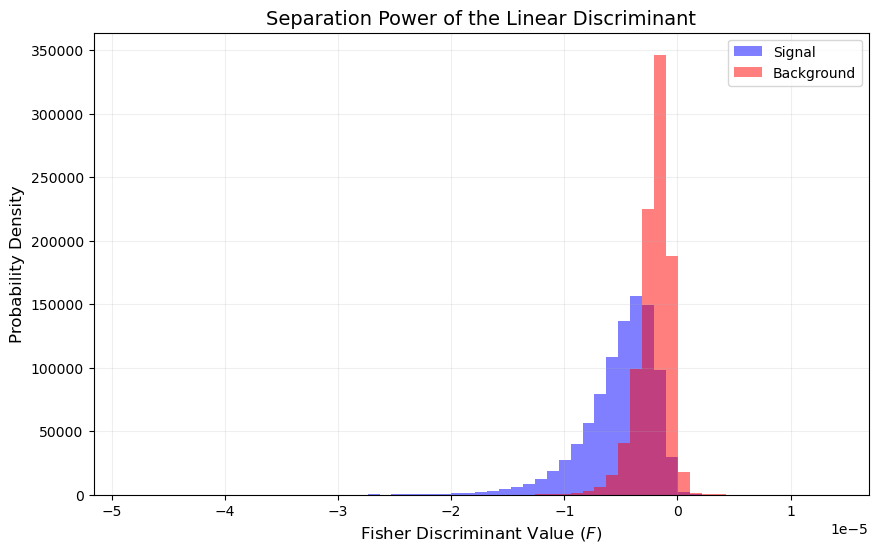

In [153]:
#exercise 8.2
import numpy as np
import matplotlib.pyplot as plt

#computing the linear Coefficients (w)
#formula:w=inv(S_W) @ (m2-m1)
m_diff=(m2 - m1) 
w=np.linalg.solve(SW,m_diff)
print(" Linear Coefficients (w) ")
#using features her:
for var,weight in zip(features,w):
    print(f"{var:>12}: {weight:.4f}")

#project the data onto the fisher axis
#F=x@w this calculates the Fisher Score for every event)
F_sig=X_sig@w
F_bkg=X_bkg@w

#plottinh the histograms of the fisher discriminant
plt.figure(figsize=(10,6))

#determining the range for the x-axis automatically
combined_min=min(F_sig.min(),F_bkg.min())
combined_max=max(F_sig.max(),F_bkg.max())
bins=np.linspace(combined_min,combined_max,60)

plt.hist(F_sig,bins=bins,alpha=0.5,label='Signal',color='blue',density=True)
plt.hist(F_bkg,bins=bins,alpha=0.5,label='Background',color='red',density=True)

plt.xlabel('Fisher Discriminant Value ($F$)',fontsize=12)
plt.ylabel('Probability Density',fontsize=12)
plt.title('Separation Power of the Linear Discriminant',fontsize=14)
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()

Generating ROC Curve for the Fisher Linear Discriminant...


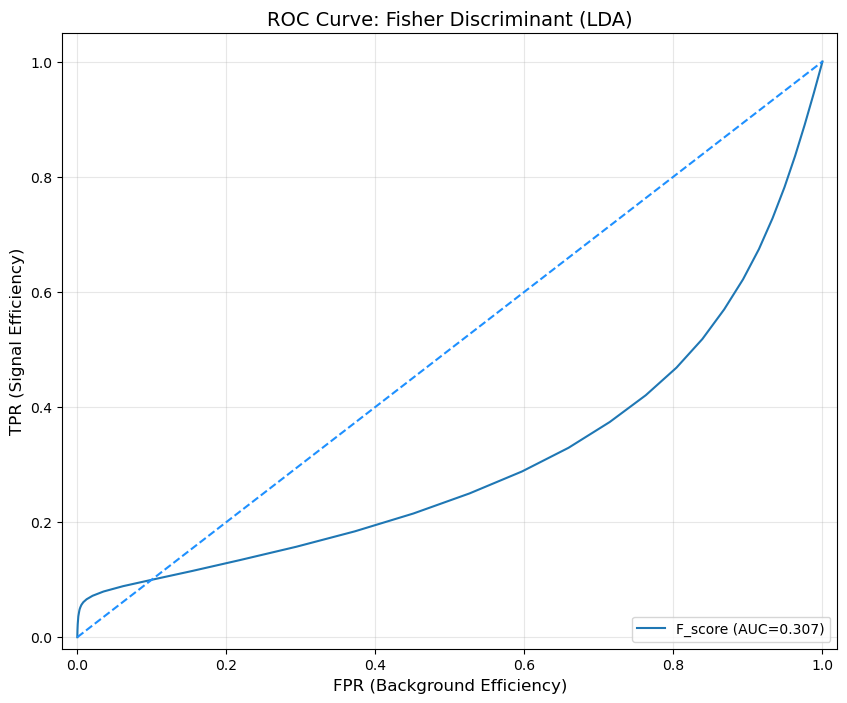

In [142]:
import pandas as pd

# 1. Prepare a temporary DataFrame for the Fisher results
# We combine the Signal and Background Fisher scores into one column
df_fisher = pd.DataFrame({
    'F_score': np.concatenate([F_sig, F_bkg]),
    'signal': np.concatenate([np.ones(len(F_sig)), np.zeros(len(F_bkg))])
})

# 2. Define the Strategy and Mean for the Fisher variable
# Usually, Fisher projects signal to higher values, so Strategy 3 or 1 works.
# Let's calculate the mean of the signal scores for our mu_dict
fisher_mu = F_sig.mean()

# Temporarily update our global dictionaries so the function can find 'F_score'
mu_dict['F_score'] = fisher_mu
best_strategy_dict['F_score'] = 3 # Signal is usually centered or 'Greater than'

# 3. Use your Exercise 7.2 function to plot the ROC
print("Generating ROC Curve for the Fisher Linear Discriminant...")
plot_roc_curves(df_fisher, ['F_score'], title="ROC Curve: Fisher Discriminant (LDA)")

In [156]:
#exercise 8.3
import numpy as np

#defining the scenarios from exercise 5
scenarios=[(10,100),(100,1000),(1000,10000),(10000,100000)]

#using the fisher projections calculated in 8.2
#F_sig and F_bkg are the projected 1D arrays
#assuming strategy 3 (centered/greater than) for the fisher variable
strat=3
mu_f=F_sig.mean()

#generating a scan range for the fisher variable
f_min=min(F_sig.min(),F_bkg.min())
f_max=max(F_sig.max(),F_bkg.max())
f_scan=np.linspace(f_min,f_max,200)

print(" Exercise 8.3: Maximal Significance (Fisher Discriminant)")

for ns_tot,nb_tot in scenarios:
    best_sig=-1
    best_xc=0
    
    for xc in f_scan:
        #calculating efficiencies for the fisher variable
        #using the raw projected arrays here
        eps_s=efficiency(F_sig,xc,strat,mu=mu_f)
        eps_b=efficiency(F_bkg,xc,strat,mu=mu_f)
        
        #calculatingexpected signal and background events
        ns_p=eps_s*ns_tot
        nb_p=eps_b*nb_tot
        
        #stabdard significance formula S/ sqrt(S + B)
        #Adding 1e-10 to prevent division by zero
        current_sig=ns_p/np.sqrt(ns_p+nb_p+1e-10)
        
        if current_sig>best_sig:
            best_sig=current_sig
            best_xc=xc
            
    print(f"Scenario Ns={ns_tot:6}: Max Significance = {best_sig:.2f} (at xc={best_xc:.3f})")

 Exercise 8.3: Maximal Significance (Fisher Discriminant)
Scenario Ns=    10: Max Significance = 0.95 (at xc=-0.000)
Scenario Ns=   100: Max Significance = 3.02 (at xc=-0.000)
Scenario Ns=  1000: Max Significance = 9.53 (at xc=-0.000)
Scenario Ns= 10000: Max Significance = 30.15 (at xc=-0.000)
